# hours级交通prediction · CatBoost 分位数回归

本 notebook 实现 [`model.md`](model.md) 方案：用 `data_autobahn/` 数据prediction **2026–2029 每天每hours**、**12 个sites** 的：

- `kfz_h` 总流量（P10/P50/P90 分位回归）
- `sv_h` 大车流量（占比法）
- `v_kfz` 平均车速（自由流基准 − 降速 两段式）

**核心思想**：把 2023–2025 主流量数据凝练成「历史画像特征」，CatBoost 在其之上用 conditional 数据（假期/天气/施工/事件）做偏移修正。无 lag、无递归。

**工程特性**：tqdm 进度条 + ETA、CatBoost 快照续训、清晰的 train/val loss 曲线、时序 hold-out 评估。

---

### 运rows顺序
0. **环境准备**（创建 `.venv` + 安装依赖 + 注册 kernel）
1. 库导入
2. **超参数配置**（§1.1 — 全部在此修改）
3. 路径与数据文件
4. 数据加载与清洗
5. 特征工程（日历 + 历史画像 + conditional）
6. CatBoost 训练（kfz_h 分位）
7. Loss 曲线
8. sv_h / v_kfz 模型
9. 评估与保存

## 0. 环境准备（venv）

首次运rows先执rows本 cell：在仓库根目录创建 `.venv`、安装依赖、注册 Jupyter kernel。

> 若当前 kernel 不在 `.venv` 中，执rows完后请在右上角切换为 **`Python (autobahn .venv)`**，Restart Kernel，再从下一节继续。

In [1]:
import subprocess
import sys
import os
from pathlib import Path

# --- 定位仓库根目录（含 data_autobahn）---
def _find_repo_root() -> Path:
    # 多个起点容错，避开 macOS 下 Path.cwd() 可能抛 PermissionError 的问题
    starts = []
    nb = globals().get("__vsc_ipynb_file__")          # VS Code 注入的 notebook 路径
    if nb:
        starts.append(Path(nb).resolve().parent)
    try:
        starts.append(Path(os.getcwd()))             # 当前工作目录（可能被权限拦截）
    except (PermissionError, OSError):
        pass
    starts.append(Path(__file__).resolve().parent if "__file__" in globals() else Path.home())

    for start in starts:
        for cand in [start, *start.parents]:
            if (cand / "data_autobahn").exists():
                return cand
    return starts[0] if starts else Path.home()


ROOT = _find_repo_root()
VENV_DIR = ROOT / ".venv"
KERNEL_NAME = "autobahn-venv"
KERNEL_DISPLAY = "Python (autobahn .venv)"

# 依赖清单：优先读仓库根目录的 requirements.txt，缺失时回退到内置默认
REQUIREMENTS_FILE = ROOT / "requirements.txt"
_DEFAULT_REQUIREMENTS = [
    "catboost>=1.2",
    "pandas>=2.0",
    "numpy",
    "matplotlib",
    "tqdm",
    "pyarrow",
    "ipykernel",
]


def _load_requirements() -> list[str]:
    if REQUIREMENTS_FILE.exists():
        reqs = []
        for line in REQUIREMENTS_FILE.read_text(encoding="utf-8").splitlines():
            line = line.split("#", 1)[0].strip()  # 去注释与空白
            if line:
                reqs.append(line)
        if reqs:
            print(f"✔ Dependency source: {REQUIREMENTS_FILE.name}({len(reqs)} items)")
            return reqs
    print("⚠ requirements.txt not found; using built-in defaults")
    return _DEFAULT_REQUIREMENTS


REQUIREMENTS = _load_requirements()



def _venv_python() -> Path:
    sub = "Scripts" if sys.platform == "win32" else "bin"
    return VENV_DIR / sub / ("python.exe" if sys.platform == "win32" else "python")


def _in_project_venv() -> bool:
    try:
        return VENV_DIR.resolve() in Path(sys.executable).resolve().parents
    except Exception:
        return False


def _run(cmd: list[str], **kwargs) -> None:
    print("$", " ".join(str(c) for c in cmd))
    subprocess.run(cmd, check=True, **kwargs)


# 1) 创建 venv（不存在或损坏则重建）
py = _venv_python()
if py.exists():
    print(f"✔ venv already exists: {VENV_DIR}")
else:
    if VENV_DIR.exists():
        import shutil
        print(f"⚠ Incomplete .venv detected (missing  {py.name}), removing and recreating...")
        shutil.rmtree(VENV_DIR, ignore_errors=True)
    print(f"Creating venv: {VENV_DIR}")
    # macOS 在 Desktop/受保护目录下用默认 symlink 建 venv 会报 EPERM(Operation not permitted)，
    # 加 --copies 复制解释器二进制即可规避；其他平台同样安全。
    _run([sys.executable, "-m", "venv", "--copies", str(VENV_DIR)])
    py = _venv_python()

if not py.exists():
    raise FileNotFoundError(f"venv python 未找到: {py}")

# 2) 安装依赖
print("\nInstalling/updating dependencies...")
_run([str(py), "-m", "pip", "install", "--upgrade", "pip"])
_run([str(py), "-m", "pip", "install", *REQUIREMENTS])

# 3) 注册 Jupyter kernel（可重复执rows）
print("\nRegistering Jupyter kernel...")
_run([
    str(py), "-m", "ipykernel", "install", "--user",
    "--name", KERNEL_NAME, "--display-name", KERNEL_DISPLAY,
])

# 4) 验证 venv 内关键包
print("\nVerifying dependency versions:")
_run([str(py), "-c",
      "import catboost, pandas, numpy, matplotlib, tqdm, pyarrow; "
      "print('catboost', catboost.__version__); "
      "print('pandas  ', pandas.__version__); "
      "print('numpy   ', numpy.__version__); "
      "print('deps OK')"])

print("-" * 56)
print(f"Repo root: {ROOT}")
print(f"venv Python: {py}")
print(f"Current kernel: {sys.executable}")
if _in_project_venv():
    print("✔ Running in project .venv; ready for subsequent cells")
else:
    print("⚠ Current kernel is NOT in .venv")
    print(f"  → Please switch kernel to: {KERNEL_DISPLAY}")
    print("  → After Restart Kernel, continue from the 'Imports' cell")

✔ Dependency source: requirements.txt(12 items)
✔ venv already exists: /Users/huang/Desktop/codenew/autobahn/Autobahn-hackathon/.venv

Installing/updating dependencies...
$ /Users/huang/Desktop/codenew/autobahn/Autobahn-hackathon/.venv/bin/python -m pip install --upgrade pip
Looking in indexes: https://pypi.tuna.tsinghua.edu.cn/simple
$ /Users/huang/Desktop/codenew/autobahn/Autobahn-hackathon/.venv/bin/python -m pip install catboost>=1.2 pandas>=2.0 numpy matplotlib tqdm pyarrow ipykernel jinja2 fastapi>=0.100 uvicorn>=0.20 openai>=1.0 anthropic>=0.20
Looking in indexes: https://pypi.tuna.tsinghua.edu.cn/simple

Registering Jupyter kernel...
$ /Users/huang/Desktop/codenew/autobahn/Autobahn-hackathon/.venv/bin/python -m ipykernel install --user --name autobahn-venv --display-name Python (autobahn .venv)
Installed kernelspec autobahn-venv in /Users/huang/Library/Jupyter/kernels/autobahn-venv

Verifying dependency versions:
$ /Users/huang/Desktop/codenew/autobahn/Autobahn-hackathon/.venv/

## 1. 库导入

> 依赖安装见上一节 **§0 环境准备**。请确认 kernel 为 `Python (autobahn .venv)`。

**超参数全部在下一节单独配置块中修改。**

In [2]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

# macOS/Linux 中文字体支持 (避免图表中文显示为方框)
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'PingFang SC', 'Heiti SC', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
from tqdm.auto import tqdm

from catboost import CatBoostRegressor, Pool

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)

/Users/linhan.li/Desktop/Autobahn-hackathon/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1.1 超参数配置（★ 全部在此修改）

训练、特征、评估、可视化的可调参数集中于此，下方代码块之外不应硬编码超参。

In [3]:
# =============================================================================
# 超参数配置块 — 修改此处即可，无需在 notebook 其他位置找 magic number
# =============================================================================

# --- 随机种子 ---
RANDOM_SEED = 42

# --- 时序切分（周期性间隔抽样，禁止随机划分）---
# ★Final Retrain: 全量 2023-01-01 ~ 2025-12-31 参与训练。
# 验证集通过每隔 N 天抽 1 天的周期性抽样产生（~10%），均匀覆盖所有季节/假期/年份。
TRAIN_END = pd.Timestamp("2025-12-31 23:59:59")
VAL_EVERY_N = 10    # 每 10 天抽 1 天做验证集（~10% hold-out，覆盖 36 个月全部季节）

# --- CatBoost 通用超参（kfz / lkw / speed 共享底座）---
CB_PARAMS = dict(
    iterations=2000,           # v2: 1500→2000，配合更小学习率收益更稳定
    learning_rate=0.02,        # v2: 0.03→0.02，小 lr + 多迭代降 MAPE 1-2pt
    depth=8,
    l2_leaf_reg=3.0,           # v2: 5.0→3.0，样本量大时可适当放宽正则
    min_data_in_leaf=50,       # v2: 100→50，允许更精细叶子捕捉假期尾部模式
    subsample=0.85,            # v2: 0.80→0.85
    random_seed=RANDOM_SEED,
    early_stopping_rounds=200, # v2: 150→200，配合更低 lr
    task_type="CPU",
    allow_writing_files=True,
)

# --- 各target模型覆盖（在 CB_PARAMS 之上 merge）---
CB_KFZ_PARAMS = dict(rsm=0.8)   # v2: 列采样，增加三分位模型间多样性 → PICP 提升
MQ_KFZ_LOSS = "MultiQuantile:alpha=0.1,0.5,0.9"  # v2: 单模型同时输出 P10/P50/P90，防分位交叉
CB_LKW_PARAMS = dict(loss_function="RMSE", eval_metric="RMSE")
CB_SPD_PARAMS = dict(
    loss_function="RMSE",
    eval_metric="RMSE",
    iterations=1200,       # v2: 1000→1200
    depth=5,
    l2_leaf_reg=15.0,      # v2: 20.0→15.0，稍放宽正则
    min_data_in_leaf=200,  # v2: 400→200，允许更细粒度速度交互
    learning_rate=0.02,    # v2: 0.025→0.02，对齐通用 lr
    early_stopping_rounds=100,
    random_strength=1.0,
    rsm=0.85,
)

# --- kfz_h 分位数 ---
QUANTILES = {"p10": 0.1, "p50": 0.5, "p90": 0.9}

# --- Model reuse / retraining ---
# If models/*.cbm already exist on disk (e.g. after git pull), the training cells
# load them and SKIP fitting. Set FORCE_RETRAIN=True to retrain from scratch.
FORCE_RETRAIN = True     # ★Final Retrain: 强制重新训练，覆写已有 .cbm

# --- Training infrastructure (snapshot resume / progress bar / fallback) ---
USE_SNAPSHOT = True
SNAPSHOT_INTERVAL_SEC = 30
FALLBACK_VERBOSE = 50     # Verbose level if snapshot resume fails (50 = moderate, avoids 200-line spam)

# --- 历史画像聚合分位 ---
PROFILE_KFZ_P90 = 0.90
PROFILE_V_P85 = 0.85

# --- speed_drop 训练target截尾 ---
SPEED_DROP_CLIP_MIN = -20.0
SPEED_DROP_CLIP_MAX = 60.0

# --- prediction后处理截断 ---
KFZ_CLIP_MIN = 0.0
LKW_RATIO_CLIP_MIN = 0.0
SPEED_CLIP_MIN = 20.0
SPEED_CLIP_MAX = 160.0

# --- 评估指标 ---
MAPE_EPS = 1.0
PEAK_QUANTILE = 0.90
PICP_TARGET_PCT = 80.0
CONFORMAL_COVERAGE = 0.80    # v2: conformal 校准target覆盖率

# --- 可视化 ---
PLOT_WEEK_START = "2025-08-01"
PLOT_WEEK_END = "2025-08-08"
PLOT_FIGSIZE = (13, 4.5)
FI_TOP_K = 20
LOSS_FIGSIZE_PER_PANEL = (5.2, 4.2)

# --- 推理演示 ---
DEMO_FORECAST_DATE = "2026-08-01"

# =============================================================================
# model.ipynb (v1) 基准指标 —— 硬编码，供最后对比表使用
# =============================================================================
V1_BASELINE = {
    "kfz_h MAE":    137.1,
    "kfz_h RMSE":   238.7,
    "kfz_h MAPE%":   16.4,
    "sv_h MAE":      24.5,
    "sv_h RMSE":     41.9,
    "sv_h MAPE%":    20.9,
    "v_kfz MAE":      5.9,
    "v_kfz RMSE":     9.6,
    "v_kfz MAPE%":    7.5,
    "PICP%":         69.5,
    "MPIW":         365.0,   # 修正: v1 真实 MPIW=365 (原误写 585)
    "Peak Recall%":  88.1,
}

np.random.seed(RANDOM_SEED)

print("Hyperparameters loaded ✔  [model_notebook.ipynb · v2]")
print(f"  ★Final Retrain: Train end: {TRAIN_END.date()}  |  Val: every {VAL_EVERY_N}th day (~{100/VAL_EVERY_N:.0f}% hold-out, all seasons)")
print(f"  CB_PARAMS: iter={CB_PARAMS['iterations']}, lr={CB_PARAMS['learning_rate']}, "
      f"depth={CB_PARAMS['depth']}, l2={CB_PARAMS['l2_leaf_reg']}, min_leaf={CB_PARAMS['min_data_in_leaf']}")
print(f"  CB_KFZ_PARAMS(v2): {CB_KFZ_PARAMS}  MQ_KFZ_LOSS={MQ_KFZ_LOSS}")
print(f"  CB_SPD_PARAMS: iter={CB_SPD_PARAMS['iterations']}, depth={CB_SPD_PARAMS['depth']}, l2={CB_SPD_PARAMS['l2_leaf_reg']}")
print(f"  Quantiles: {QUANTILES}  |  conformal target: {CONFORMAL_COVERAGE:.0%}")
print(f"  v1 baseline PICP={V1_BASELINE['PICP%']}%  →  target {PICP_TARGET_PCT:.0f}%")


Hyperparameters loaded ✔  [model_notebook.ipynb · v2]
  ★Final Retrain: Train end: 2025-12-31  |  Val: every 10th day (~10% hold-out, all seasons)
  CB_PARAMS: iter=2000, lr=0.02, depth=8, l2=3.0, min_leaf=50
  CB_KFZ_PARAMS(v2): {'rsm': 0.8}  MQ_KFZ_LOSS=MultiQuantile:alpha=0.1,0.5,0.9
  CB_SPD_PARAMS: iter=1200, depth=5, l2=15.0
  Quantiles: {'p10': 0.1, 'p50': 0.5, 'p90': 0.9}  |  conformal target: 80%
  v1 baseline PICP=69.5%  →  target 80%


## 1.2 路径与数据文件

In [4]:
import os


def find_root() -> Path:
    # 依次尝试多个起点，避开 macOS 下 Path.cwd() 可能抛 PermissionError 的问题
    starts = []
    nb = globals().get("__vsc_ipynb_file__")          # VS Code 注入的 notebook 路径
    if nb:
        starts.append(Path(nb).resolve().parent)
    try:
        starts.append(Path(os.getcwd()))             # 当前工作目录（可能被权限拦截）
    except (PermissionError, OSError):
        pass
    starts.append(Path(__file__).resolve().parent if "__file__" in globals() else Path.home())

    for start in starts:
        for cand in [start, *start.parents]:
            if (cand / "data_autobahn").exists():
                return cand
    raise FileNotFoundError("未找到 data_autobahn 目录")


ROOT = find_root()
DATA_DIR = ROOT / "data_autobahn"
MODEL_DIR = ROOT / "models"
SNAP_DIR = ROOT / "models" / "snapshots"
PROC_DIR = ROOT / "processed"
# 三个target各自的模型子文件夹
KFZ_DIR = MODEL_DIR / "kfz_h"      # 总流量分位模型 p10/p50/p90.cbm
SV_DIR = MODEL_DIR / "sv_h"        # 大车占比模型 lkw_ratio.cbm
VKFZ_DIR = MODEL_DIR / "v_kfz"     # 车速降速模型 speed_drop.cbm
for d in (MODEL_DIR, SNAP_DIR, PROC_DIR, KFZ_DIR, SV_DIR, VKFZ_DIR):
    d.mkdir(parents=True, exist_ok=True)

FILES = {
    "traffic": DATA_DIR / "合并表格，小时交通流量.csv",
    "temp": DATA_DIR / "合并表格，时间，气温，路温.csv",
    "holiday": DATA_DIR / "合并表格，holiday日级.csv",
    "weather": DATA_DIR / "合并表格，weather日级.csv",
    "construction": DATA_DIR / "合并表格，construction日级.csv",
    "events": DATA_DIR / "合并表格，special_events日级.csv",
}

print("ROOT      :", ROOT)
print("DATA_DIR  :", DATA_DIR)
print("Model subdirs:", KFZ_DIR.name, "/", SV_DIR.name, "/", VKFZ_DIR.name)
for k, v in FILES.items():
    print(f"  {k:13s}: {'OK' if v.exists() else 'MISSING'}  {v.name}")


ROOT      : /Users/linhan.li/Desktop/Autobahn-hackathon
DATA_DIR  : /Users/linhan.li/Desktop/Autobahn-hackathon/data_autobahn
Model subdirs: kfz_h / sv_h / v_kfz
  traffic      : OK  合并表格，小时交通流量.csv
  temp         : OK  合并表格，时间，气温，路温.csv
  holiday      : OK  合并表格，holiday日级.csv
  weather      : OK  合并表格，weather日级.csv
  construction : OK  合并表格，construction日级.csv
  events       : OK  合并表格，special_events日级.csv


## 2. 数据加载与清洗

所有表分隔符 `;`，**第 2 rows是中文说明**（读取时跳过），部分列用逗号小数。

In [5]:
def read_semicolon(path: Path) -> pd.DataFrame:
    """读取分号分隔表，跳过第 2 rows中文说明。"""
    return pd.read_csv(path, sep=";", skiprows=[1], dtype=str, keep_default_na=True)


def to_num(series: pd.Series) -> pd.Series:
    """逗号小数 -> 浮点。"""
    return pd.to_numeric(
        series.astype(str).str.replace(",", ".", regex=False).replace({"nan": np.nan, "": np.nan}),
        errors="coerce",
    )


# ---------- 2.1 主表：hours交通流量 ----------
traffic = read_semicolon(FILES["traffic"])
for c in ["bab_km", "longitude", "latitude", "kfz_h", "sv_h", "v_kfz"]:
    traffic[c] = to_num(traffic[c])

# 时间戳：datum=DD.MM.YYYY, t_start=HH:MM:SS
traffic["ts"] = pd.to_datetime(
    traffic["datum"] + " " + traffic["t_start"], format="%d.%m.%Y %H:%M:%S", errors="coerce"
)
traffic = traffic.dropna(subset=["ts"]).copy()
traffic["date"] = traffic["ts"].dt.normalize()
traffic["hour"] = traffic["ts"].dt.hour
traffic["weekday"] = traffic["wochentag"].astype(int)          # 1-7
traffic["site_id"] = traffic["road"] + "_" + traffic["direction"] + "_" + traffic["site_name"]

# 异常处理：物理不可能值 -> NaN
traffic.loc[traffic["kfz_h"] < 0, "kfz_h"] = np.nan
traffic.loc[traffic["sv_h"] < 0, "sv_h"] = np.nan
# v_kfz 仅在 kfz_h>0 时有效
traffic.loc[(traffic["kfz_h"].isna()) | (traffic["kfz_h"] <= 0), "v_kfz"] = np.nan

print("Traffic table rows:", len(traffic))
print("Sites:", traffic["site_id"].nunique(), "->", sorted(traffic["site_id"].unique()))
print("Time range:", traffic["ts"].min(), "~", traffic["ts"].max())
traffic[["site_id", "ts", "hour", "weekday", "tagestyp", "kfz_h", "sv_h", "v_kfz"]].head()

Traffic table rows: 315648
Sites: 12 -> ['A8_Mch_MQB25_Mch_H', 'A8_Mch_MQQ209_Mch_H', 'A8_Mch_MQQ245_Mch_H', 'A8_Sbg_MQQ213_Sbg_H', 'A8_Sbg_MQQ245_Sbg_H', 'A8_Sbg_MQQ37_Sbg_H', 'A93_Kff_MQDZ_AD Inntal_(S)_Kff', 'A93_Kff_MQDZ_Kiefersfelden_(S)_Kff', 'A93_Kff_MQ_Gletschergarten_Kff', 'A93_Ro_MQDZ_AD Inntal_(S)_Ro', 'A93_Ro_MQDZ_Kiefersfelden_(S)_Ro', 'A93_Ro_MQ_Gletschergarten_Ro']
Time range: 2023-01-01 00:00:00 ~ 2025-12-31 23:00:00


,site_id,ts,hour,weekday,tagestyp,kfz_h,sv_h,v_kfz
0,A8_Mch_MQB25_Mch_H,2023-01-01,0,7,s,255.0,17.0,140.0
1,A8_Mch_MQQ209_Mch_H,2023-01-01,0,7,s,132.0,13.0,125.6
2,A8_Mch_MQQ245_Mch_H,2023-01-01,0,7,s,159.0,17.0,126.3
3,A8_Sbg_MQQ213_Sbg_H,2023-01-01,0,7,s,91.0,10.0,116.5
4,A8_Sbg_MQQ245_Sbg_H,2023-01-01,0,7,s,71.0,9.0,112.0


In [6]:
# ---------- 2.2 温度表（分钟）-> hours聚合 ----------
# t_start;lt;fbt   (lt=气温, fbt=路温)，dot 小数
temp_raw = read_semicolon(FILES["temp"])
temp_raw["lt"] = to_num(temp_raw["lt"])
temp_raw["fbt"] = to_num(temp_raw["fbt"])
temp_raw["ts"] = pd.to_datetime(temp_raw["t_start"], errors="coerce")
temp_raw = temp_raw.dropna(subset=["ts"]).copy()
temp_raw["date"] = temp_raw["ts"].dt.normalize()
temp_raw["hour"] = temp_raw["ts"].dt.hour

temp_hourly = (
    temp_raw.groupby(["date", "hour"])
    .agg(lt_mean=("lt", "mean"), fbt_mean=("fbt", "mean"), fbt_min=("fbt", "min"))
    .reset_index()
)

# 气候态 (month, hour) 备用：未来/缺测回填
temp_hourly["month"] = temp_hourly["date"].dt.month
temp_climo = (
    temp_hourly.groupby(["month", "hour"])
    .agg(lt_mean_c=("lt_mean", "mean"), fbt_mean_c=("fbt_mean", "mean"), fbt_min_c=("fbt_min", "mean"))
    .reset_index()
)
print("Temp hourly table:", temp_hourly.shape, "| climatology:", temp_climo.shape)
temp_hourly.head()

Temp hourly table: (25780, 6) | climatology: (288, 5)


,date,hour,lt_mean,fbt_mean,fbt_min,month
0,2023-01-01,0,11.018644,6.210169,5.8,1
1,2023-01-01,1,9.570000,5.561667,5.3,1
2,2023-01-01,2,6.171667,4.870000,4.2,1
3,2023-01-01,3,4.750000,3.808333,3.6,1
4,2023-01-01,4,9.780000,4.855000,3.6,1


In [7]:
# ---------- 2.3 conditional 日级表 ----------
def load_daily(path: Path, num_cols, cat_cols):
    df = read_semicolon(path)
    df["date"] = pd.to_datetime(df["date"], errors="coerce").dt.normalize()
    for c in num_cols:
        if c in df.columns:
            df[c] = to_num(df[c]).fillna(0)
    for c in cat_cols:
        if c in df.columns:
            df[c] = df[c].fillna("").astype(str)
    keep = ["date"] + [c for c in (num_cols + cat_cols) if c in df.columns]
    return df[keep].drop_duplicates("date")


holiday = load_daily(
    FILES["holiday"],
    num_cols=[
        "is_school_holiday_DE_BY", "is_school_holiday_AT_SB", "is_school_holiday_AT_TI",
        "is_public_holiday_DE_BY", "is_public_holiday_AT_SB", "is_public_holiday_AT_TI",
        "school_holiday_count", "public_holiday_count",
        "is_holiday_start", "is_holiday_end", "in_traffic_window",
    ],
    cat_cols=["window_direction", "window_risk_level", "a8_direction", "a93_direction"],
)

# v2：派生假期距离特征（出发/返程波识别）—— 在 holiday 日级表上计算，随 merge_conditional 合入主表
def _add_holiday_proximity(hol: pd.DataFrame) -> pd.DataFrame:
    h = hol.sort_values("date").copy().reset_index(drop=True)
    # 下一个假期开始日（前向填充到达每天"距下次开始还有几天"）
    h["_ns"] = h.loc[h["is_holiday_start"] == 1, "date"]
    h["_ns"] = h["_ns"].bfill()
    h["days_to_holiday_start"] = (h["_ns"] - h["date"]).dt.days.clip(0, 30).fillna(30).astype(int)
    # 上一个假期结束日（后向填充）
    h["_le"] = h.loc[h["is_holiday_end"] == 1, "date"]
    h["_le"] = h["_le"].ffill()
    h["days_since_holiday_end"] = (h["date"] - h["_le"]).dt.days.clip(0, 30).fillna(30).astype(int)
    # 跨地区假期叠加热度
    h["total_holiday_overlap"] = (h["school_holiday_count"] + h["public_holiday_count"]).clip(0, 6)
    # 出发波：假期开始前 ≤7 天内的周六（= 出rows峰最大堵点）
    _dow = h["date"].dt.weekday   # 0=Mon, 5=Sat, 6=Sun
    h["is_departure_wave_day"] = (
        (_dow == 5) & (h["days_to_holiday_start"] > 0) & (h["days_to_holiday_start"] <= 7)
    ).astype(int)
    # 返程波：假期结束后 ≤7 天内的周日
    h["is_return_wave_day"] = (
        (_dow == 6) & (h["days_since_holiday_end"] > 0) & (h["days_since_holiday_end"] <= 7)
    ).astype(int)
    return h.drop(columns=["_ns", "_le"])

holiday = _add_holiday_proximity(holiday)
print("  Holiday distance features (v2):", ["days_to_holiday_start", "days_since_holiday_end",
                               "total_holiday_overlap", "is_departure_wave_day", "is_return_wave_day"])

weather = read_semicolon(FILES["weather"])
weather["date"] = pd.to_datetime(weather["date"], errors="coerce").dt.normalize()
for c in ["precip_mm", "snowfall_mm", "low_vis_hours", "t_min_c", "t_max_c", "has_ice_risk",
          "precip_mm_mean", "low_vis_hours_mean", "ice_risk_prob", "t_min_c_mean", "t_max_c_mean"]:
    if c in weather.columns:
        weather[c] = to_num(weather[c])
# observed 优先, 缺失回填 climatology
weather["w_precip"] = weather["precip_mm"].fillna(weather.get("precip_mm_mean"))
weather["w_snow"] = weather["snowfall_mm"].fillna(0)
weather["w_lowvis"] = weather["low_vis_hours"].fillna(weather.get("low_vis_hours_mean"))
weather["w_tmin"] = weather["t_min_c"].fillna(weather.get("t_min_c_mean"))
weather["w_tmax"] = weather["t_max_c"].fillna(weather.get("t_max_c_mean"))
weather["w_ice"] = weather["has_ice_risk"].fillna(weather.get("ice_risk_prob"))
weather["weather_source"] = weather["weather_source"].fillna("climatology").astype(str)
weather = weather[["date", "w_precip", "w_snow", "w_lowvis", "w_tmin", "w_tmax", "w_ice", "weather_source"]]

construction = load_daily(
    FILES["construction"],
    num_cols=[
        "has_a8_construction", "has_a93_construction", "a8_construction_count", "a93_construction_count",
        "has_2_plus_0", "two_plus_0_count", "max_closed_lanes", "sum_closed_lanes",
        "has_target_bbox_construction",
    ],
    cat_cols=[],
)

events = load_daily(
    FILES["events"],
    num_cols=[
        "has_special_event", "active_event_count", "max_impact_level", "impact_score",
        "affects_a8_ost", "affects_a93_sued",
        "has_munich_event", "has_salzburg_event", "has_rosenheim_event", "has_kufstein_event",
        "has_confirmed_event", "has_estimated_event",
    ],
    cat_cols=[],
)

print("holiday     :", holiday.shape)
print("weather     :", weather.shape)
print("construction:", construction.shape)
print("events      :", events.shape)
holiday.head(3)

  Holiday distance features (v2): ['days_to_holiday_start', 'days_since_holiday_end', 'total_holiday_overlap', 'is_departure_wave_day', 'is_return_wave_day']
holiday     : (2557, 21)
weather     : (2557, 8)
construction: (2557, 10)
events      : (2557, 13)


,date,is_school_holiday_DE_BY,is_school_holiday_AT_SB,is_school_holiday_AT_TI,is_public_holiday_DE_BY,is_public_holiday_AT_SB,is_public_holiday_AT_TI,school_holiday_count,public_holiday_count,is_holiday_start,is_holiday_end,in_traffic_window,window_direction,window_risk_level,a8_direction,a93_direction,days_to_holiday_start,days_since_holiday_end,total_holiday_overlap,is_departure_wave_day,is_return_wave_day
0,2023-01-01,1,1,1,1,1,1,3,3,1,1,0,,,,,0,0,6,0,0
1,2023-01-02,1,1,1,0,0,0,3,0,0,0,0,,,,,4,1,3,0,0
2,2023-01-03,1,1,1,0,0,0,3,0,0,0,0,,,,,3,2,3,0,0


## 3. 特征工程

- **日历特征**：周期 sin/cos 编码
- **历史画像特征**：从训练集按日历键聚合（out-of-fold，防泄漏）—— 主流量信号入模的核心方式
- **conditional 合并**：假期/天气/温度/施工/事件 left join

In [8]:
# ---------- 3.1 日历特征 ----------
def add_calendar(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    d = df["date"]
    df["month"] = d.dt.month
    df["doy"] = d.dt.dayofyear
    df["week_of_year"] = d.dt.isocalendar().week.astype(int)
    df["is_weekend"] = (df["weekday"] >= 6).astype(int)
    df["is_friday"] = (df["weekday"] == 5).astype(int)
    df["is_saturday"] = (df["weekday"] == 6).astype(int)
    df["is_sunday"] = (df["weekday"] == 7).astype(int)
    # 周期编码
    df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
    df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)
    df["dow_sin"] = np.sin(2 * np.pi * (df["weekday"] - 1) / 7)
    df["dow_cos"] = np.cos(2 * np.pi * (df["weekday"] - 1) / 7)
    df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
    df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)
    df["doy_sin"] = np.sin(2 * np.pi * df["doy"] / 365.25)
    df["doy_cos"] = np.cos(2 * np.pi * df["doy"] / 365.25)
    # 季节
    season_map = {12: "winter", 1: "winter", 2: "winter", 3: "spring", 4: "spring", 5: "spring",
                  6: "summer", 7: "summer", 8: "summer", 9: "autumn", 10: "autumn", 11: "autumn"}
    df["season"] = df["month"].map(season_map)
    return df


# ---------- 3.2 conditional + 温度 合并 ----------
def merge_conditional(df: pd.DataFrame) -> pd.DataFrame:
    df = df.merge(holiday, on="date", how="left")
    df = df.merge(weather, on="date", how="left")
    df = df.merge(construction, on="date", how="left")
    df = df.merge(events, on="date", how="left")
    df = df.merge(temp_hourly[["date", "hour", "lt_mean", "fbt_mean", "fbt_min"]],
                  on=["date", "hour"], how="left")
    # 温度缺失 -> (month, hour) 气候态
    df = df.merge(temp_climo, on=["month", "hour"], how="left")
    df["lt_mean"] = df["lt_mean"].fillna(df["lt_mean_c"])
    df["fbt_mean"] = df["fbt_mean"].fillna(df["fbt_mean_c"])
    df["fbt_min"] = df["fbt_min"].fillna(df["fbt_min_c"])
    df = df.drop(columns=["lt_mean_c", "fbt_mean_c", "fbt_min_c"])
    # 类别列空值补占位
    for c in ["weather_source", "window_direction", "window_risk_level", "a8_direction", "a93_direction"]:
        if c in df.columns:
            df[c] = df[c].fillna("none").replace("", "none").astype(str)
    return df


def derive_tagestyp(df: pd.DataFrame) -> pd.Series:
    """用日历 + holiday flags 重建 tagestyp（优先级 s>u>w）。
    经 2023–2025 真值验证：准确率 99.91%（1096 天仅 1 天偏差）。
      s = 周日 或 公共假日(DE-BY)
      u = 学校假期(DE-BY) 且非 s   （CLAUDE.md H3: u ≡ is_school_holiday_DE_BY）
      w = 其余
    用于未来网格推理，消除「暑假被当工作日」的 train/serve skew。
    要求 df 已含 weekday，且 merge_conditional 后含 is_public/school_holiday_DE_BY。
    """
    wd = df["weekday"].astype(int)
    pub = pd.to_numeric(df.get("is_public_holiday_DE_BY", 0), errors="coerce").fillna(0)
    sch = pd.to_numeric(df.get("is_school_holiday_DE_BY", 0), errors="coerce").fillna(0)
    return pd.Series(
        np.where((wd == 7) | (pub == 1), "s", np.where(sch == 1, "u", "w")),
        index=df.index,
    )


base = add_calendar(traffic)
base["lkw_ratio"] = np.where(base["kfz_h"] > 0, base["sv_h"] / base["kfz_h"], np.nan)
base = merge_conditional(base)
print("Merged feature table:", base.shape)
print("Columns with NaN (top 20):")
print(base.isna().sum().sort_values(ascending=False).head(20))
base.head(3)

Merged feature table: (315648, 87)
Columns with NaN (top 20):
v_kfz                     32382
lkw_ratio                 32075
sv_h                      31985
kfz_h                     31985
has_a93_construction          0
has_a8_construction           0
weather_source                0
w_ice                         0
w_tmax                        0
w_tmin                        0
w_lowvis                      0
w_snow                        0
w_precip                      0
road                          0
a93_construction_count        0
is_return_wave_day            0
is_departure_wave_day         0
total_holiday_overlap         0
days_since_holiday_end        0
days_to_holiday_start         0
dtype: int64


,road,direction,site_name,bab_km,longitude,latitude,devices,datum,t_start,wochentag,tagestyp,kfz_h,sv_h,v_kfz,ts,date,hour,weekday,site_id,month,doy,week_of_year,is_weekend,is_friday,is_saturday,is_sunday,hour_sin,hour_cos,dow_sin,dow_cos,month_sin,month_cos,doy_sin,doy_cos,season,lkw_ratio,is_school_holiday_DE_BY,is_school_holiday_AT_SB,is_school_holiday_AT_TI,is_public_holiday_DE_BY,is_public_holiday_AT_SB,is_public_holiday_AT_TI,school_holiday_count,public_holiday_count,is_holiday_start,is_holiday_end,in_traffic_window,window_direction,window_risk_level,a8_direction,a93_direction,days_to_holiday_start,days_since_holiday_end,total_holiday_overlap,is_departure_wave_day,is_return_wave_day,w_precip,w_snow,w_lowvis,w_tmin,w_tmax,w_ice,weather_source,has_a8_construction,has_a93_construction,a8_construction_count,a93_construction_count,has_2_plus_0,two_plus_0_count,max_closed_lanes,sum_closed_lanes,has_target_bbox_construction,has_special_event,active_event_count,max_impact_level,impact_score,affects_a8_ost,affects_a93_sued,has_munich_event,has_salzburg_event,has_rosenheim_event,has_kufstein_event,has_confirmed_event,has_estimated_event,lt_mean,fbt_mean,fbt_min
0,A8,Mch,MQB25_Mch_H,20.090,11.704721,47.936450,"9171_MQB25_Mch_H,DE33,34,35,36",01.01.2023,00:00:00,7,s,255.0,17.0,140.0,2023-01-01,2023-01-01,0,7,A8_Mch_MQB25_Mch_H,1,1,52,1,0,0,1,0.0,1.0,-0.781831,0.62349,0.5,0.866025,0.017202,0.999852,winter,0.066667,1,1,1,1,1,1,3,3,1,1,0,none,none,none,none,0,0,6,0,0,0.0,0.0,0.0,5.7,15.6,0.0,observed,0,0,0,0,0,0,0,0,0,0,0,0.0,0,0,0,0,0,0,0,0,0,11.018644,6.210169,5.8
1,A8,Mch,MQQ209_Mch_H,93.384,12.564707,47.826446,"9192_MQQ209_Mch_H,DE33,34",01.01.2023,00:00:00,7,s,132.0,13.0,125.6,2023-01-01,2023-01-01,0,7,A8_Mch_MQQ209_Mch_H,1,1,52,1,0,0,1,0.0,1.0,-0.781831,0.62349,0.5,0.866025,0.017202,0.999852,winter,0.098485,1,1,1,1,1,1,3,3,1,1,0,none,none,none,none,0,0,6,0,0,0.0,0.0,0.0,5.7,15.6,0.0,observed,0,0,0,0,0,0,0,0,0,0,0,0.0,0,0,0,0,0,0,0,0,0,11.018644,6.210169,5.8
2,A8,Mch,MQQ245_Mch_H,106.270,12.733767,47.830867,"9194_MQQ245_Mch_H,DE33,34",01.01.2023,00:00:00,7,s,159.0,17.0,126.3,2023-01-01,2023-01-01,0,7,A8_Mch_MQQ245_Mch_H,1,1,52,1,0,0,1,0.0,1.0,-0.781831,0.62349,0.5,0.866025,0.017202,0.999852,winter,0.106918,1,1,1,1,1,1,3,3,1,1,0,none,none,none,none,0,0,6,0,0,0.0,0.0,0.0,5.7,15.6,0.0,observed,0,0,0,0,0,0,0,0,0,0,0,0.0,0,0,0,0,0,0,0,0,0,11.018644,6.210169,5.8


In [9]:
# ---------- 3.3 时序切分（周期性间隔抽样） ----------
# 覆盖 2023-01-01 ~ 2025-12-31 全量数据。
# 每 VAL_EVERY_N 天抽 1 天做验证集，均匀分布在所有 36 个月内，
# 确保每个季节、每种假期类型、每种天气模式都在 Early Stopping 中被监控。
# 确定性取模保证每次运行划分一致；非随机，相邻天不会泄漏到 train/val 两侧。
base_filtered = base[base["ts"] <= TRAIN_END].copy()
unique_dates = np.sort(base_filtered["date"].unique())
val_dates = unique_dates[::VAL_EVERY_N]          # 每第 10 天 → 验证集

val_mask = base_filtered["date"].isin(val_dates)
train_mask = ~val_mask
train_df = base_filtered[train_mask].copy()
val_df = base_filtered[val_mask].copy()

n_dates = len(unique_dates)
n_val_dates = len(val_dates)
print(f"Periodic hold-out: every {VAL_EVERY_N}th day → {n_val_dates}/{n_dates} val dates (~{100*n_val_dates/n_dates:.1f}%)")
print(f"Train: {len(train_df):>8,} rows  ({train_df['ts'].min().date()} ~ {train_df['ts'].max().date()})")
print(f"Val:   {len(val_df):>8,} rows  ({val_df['ts'].min().date()} ~ {val_df['ts'].max().date()})  "
      f"— covers all seasons uniformly")


# ---------- 3.4 历史画像特征（仅用训练集聚合，防泄漏）----------
def build_profiles(tr: pd.DataFrame) -> dict:
    tr = tr[tr["kfz_h"].notna()]
    return {
        "prof_kfz_shd": tr.groupby(["site_id", "hour", "weekday"])["kfz_h"].median().rename("prof_kfz_shd"),
        "prof_kfz_sht": tr.groupby(["site_id", "hour", "tagestyp"])["kfz_h"].median().rename("prof_kfz_sht"),
        "prof_kfz_shm": tr.groupby(["site_id", "hour", "month"])["kfz_h"].median().rename("prof_kfz_shm"),
        "prof_kfz_p90": tr.groupby(["site_id", "hour", "weekday"])["kfz_h"].quantile(PROFILE_KFZ_P90).rename("prof_kfz_p90"),
        "prof_lkw_shd": tr[tr["lkw_ratio"].notna()].groupby(["site_id", "hour", "weekday"])["lkw_ratio"].median().rename("prof_lkw_shd"),
        "prof_v_shd": tr[tr["v_kfz"].notna()].groupby(["site_id", "hour", "weekday"])["v_kfz"].median().rename("prof_v_shd"),
        "prof_v_p85": tr[tr["v_kfz"].notna()].groupby(["site_id", "hour"])["v_kfz"].quantile(PROFILE_V_P85).rename("prof_v_p85"),
        # v2: 新增三个画像 — 季节维度 + 日类型维度大车/车速
        "prof_kfz_shs": tr.groupby(["site_id", "hour", "season"])["kfz_h"].median().rename("prof_kfz_shs"),
        "prof_lkw_sht": tr[tr["lkw_ratio"].notna()].groupby(["site_id", "hour", "tagestyp"])["lkw_ratio"].median().rename("prof_lkw_sht"),
        "prof_v_sht": tr[tr["v_kfz"].notna()].groupby(["site_id", "hour", "tagestyp"])["v_kfz"].median().rename("prof_v_sht"),
    }


def apply_profiles(df: pd.DataFrame, profs: dict) -> pd.DataFrame:
    df = df.copy()
    keys = {
        "prof_kfz_shd": ["site_id", "hour", "weekday"],
        "prof_kfz_sht": ["site_id", "hour", "tagestyp"],
        "prof_kfz_shm": ["site_id", "hour", "month"],
        "prof_kfz_p90": ["site_id", "hour", "weekday"],
        "prof_lkw_shd": ["site_id", "hour", "weekday"],
        "prof_v_shd": ["site_id", "hour", "weekday"],
        "prof_v_p85": ["site_id", "hour"],
        # v2: 新增
        "prof_kfz_shs": ["site_id", "hour", "season"],
        "prof_lkw_sht": ["site_id", "hour", "tagestyp"],
        "prof_v_sht":   ["site_id", "hour", "tagestyp"],
    }
    for name, k in keys.items():
        df = df.merge(profs[name], on=k, how="left")
    # 残余缺失用全局中位数兜底
    for name in keys:
        if df[name].isna().any():
            df[name] = df[name].fillna(df[name].median())
    return df


profiles = build_profiles(train_df)
train_df = apply_profiles(train_df, profiles)
val_df = apply_profiles(val_df, profiles)
print("Profile features added. Sample columns:", [c for c in train_df.columns if c.startswith("prof_")])

Periodic hold-out: every 10th day → 110/1096 val dates (~10.0%)
Train:  283,968 rows  (2023-01-02 ~ 2025-12-31)
Val:     31,680 rows  (2023-01-01 ~ 2025-12-26)  — covers all seasons uniformly
Profile features added. Sample columns: ['prof_kfz_shd', 'prof_kfz_sht', 'prof_kfz_shm', 'prof_kfz_p90', 'prof_lkw_shd', 'prof_v_shd', 'prof_v_p85', 'prof_kfz_shs', 'prof_lkw_sht', 'prof_v_sht']


In [10]:
# ---------- 3.5 特征清单 ----------
CALENDAR = [
    "hour", "weekday", "month", "doy", "week_of_year",
    "is_weekend", "is_friday", "is_saturday", "is_sunday",
    "hour_sin", "hour_cos", "dow_sin", "dow_cos",
    "month_sin", "month_cos", "doy_sin", "doy_cos",
]
STATIC_NUM = ["bab_km", "longitude", "latitude"]
STATIC_CAT = ["site_id", "road", "direction", "site_name", "tagestyp", "season"]

HOLIDAY = [
    "is_school_holiday_DE_BY", "is_school_holiday_AT_SB", "is_school_holiday_AT_TI",
    "is_public_holiday_DE_BY", "is_public_holiday_AT_SB", "is_public_holiday_AT_TI",
    "school_holiday_count", "public_holiday_count",
    "is_holiday_start", "is_holiday_end", "in_traffic_window",
    # v2: 距离特征
    "days_to_holiday_start", "days_since_holiday_end", "total_holiday_overlap",
    "is_departure_wave_day", "is_return_wave_day",
]
HOLIDAY_CAT = ["window_direction", "window_risk_level", "a8_direction", "a93_direction"]
WEATHER = ["w_precip", "w_snow", "w_lowvis", "w_tmin", "w_tmax", "w_ice"]
WEATHER_CAT = ["weather_source"]
TEMP = ["lt_mean", "fbt_mean", "fbt_min"]
CONSTRUCTION = [
    "has_a8_construction", "has_a93_construction", "a8_construction_count", "a93_construction_count",
    "has_2_plus_0", "two_plus_0_count", "max_closed_lanes", "sum_closed_lanes", "has_target_bbox_construction",
]
EVENTS = [
    "has_special_event", "active_event_count", "max_impact_level", "impact_score",
    "affects_a8_ost", "affects_a93_sued",
    "has_munich_event", "has_salzburg_event", "has_rosenheim_event", "has_kufstein_event",
    "has_confirmed_event", "has_estimated_event",
]

PROF_KFZ = ["prof_kfz_shd", "prof_kfz_sht", "prof_kfz_shm", "prof_kfz_p90", "prof_kfz_shs"]  # v2: +shs
PROF_LKW = ["prof_lkw_shd", "prof_lkw_sht"]  # v2: +sht
PROF_V = ["prof_v_shd", "prof_v_p85", "prof_v_sht"]  # v2: +sht

COND = HOLIDAY + HOLIDAY_CAT + WEATHER + WEATHER_CAT + TEMP + CONSTRUCTION + EVENTS
CAT_FEATURES = STATIC_CAT + HOLIDAY_CAT + WEATHER_CAT

# 各target的特征集合
FEATURES_KFZ = CALENDAR + STATIC_NUM + STATIC_CAT + PROF_KFZ + COND
FEATURES_LKW = CALENDAR + STATIC_NUM + STATIC_CAT + PROF_KFZ + PROF_LKW + COND
FEATURES_SPD = CALENDAR + STATIC_NUM + STATIC_CAT + PROF_KFZ + PROF_V + COND + ["kfz_p50_pred"]  # G3: speed model sees flow prediction

# Feature groups for factor explanation (per-row + per-day attribution).
# Each feature in FEATURES_KFZ belongs to exactly one group; groups are human-readable
# and intended for the Agent layer to show end users. See doc/FACTOR_CONTRIBUTIONS.md.
#
# v4 change: 7 groups (was 6). "Typical Traffic" split into "Station & Location" + "Historical Patterns"
# so the Agent can distinguish "where the road is" from "what the data says." tagestyp moved from
# Calendar to Holiday Effect for a complete holiday signal. Output format is SHAP-compatible
# (full names, 1 decimal %, Chinese semicolons) — fits the Agent's existing parsing code.
EXPLANATION_GROUPS = {
    # 🆕 拆分 TT 为两个独立维度
    "Station & Location":       ["site_id", "road", "direction", "site_name"] + STATIC_NUM,
    "Historical Patterns":      PROF_KFZ,

    # 🔧 CA 移除 tagestyp，只保留纯时间特征
    "Calendar & Season":        CALENDAR + ["season"],

    # 🔧 HO 加入 tagestyp，假日信号完整
    "Holiday Effect":           HOLIDAY + HOLIDAY_CAT + ["tagestyp"],

    # ✅ 不变
    "Weather & Road":           WEATHER + WEATHER_CAT + TEMP,
    "Special Events":           EVENTS,
    "Construction":             CONSTRUCTION,
}
# Short codes used internally. Display names (FACTOR_DISPLAY) are used for the Agent-facing output (forecast_2026_daily.csv).
FACTOR_ABBR = {
    "Station & Location":       "SL",
    "Historical Patterns":      "HP",
    "Calendar & Season":        "CA",
    "Holiday Effect":           "HO",
    "Weather & Road":           "WE",
    "Special Events":           "EV",
    "Construction":             "CO",
}
# SHAP-compatible display names for the Agent layer (forecast_2026_daily.csv).
# These match the column names the Agent already reads from add_daily_forecast_reasons.py.
FACTOR_DISPLAY = {
    "Station & Location":       "Road Segment and Detector Attributes",
    "Historical Patterns":      "Historical Traffic Baseline",
    "Calendar & Season":        "Date and Time Pattern",
    "Holiday Effect":           "Holiday Effect",
    "Weather & Road":           "Weather and Temperature",
    "Special Events":           "Special Events",
    "Construction":             "Construction Impact",
}
# Validate coverage: every feature in FEATURES_KFZ must be in exactly one group
_explained = set()
_seen = set()
for _g, _feats in EXPLANATION_GROUPS.items():
    for _f in _feats:
        assert _f in FEATURES_KFZ, f"{_f} (group {_g}) not in FEATURES_KFZ"
        assert _f not in _seen, f"{_f} appears in multiple groups"
        _seen.add(_f)
        _explained.add(_f)
_MISSING = [f for f in FEATURES_KFZ if f not in _explained]
assert not _MISSING, f"Features not in any explanation group: {_MISSING}"
print(f"Factor explanation: {len(_explained)}/{len(FEATURES_KFZ)} features covered across {len(EXPLANATION_GROUPS)} groups")


def make_pool(df, features, target, weight=None):
    cats = [c for c in CAT_FEATURES if c in features]
    X = df[features].copy()
    for c in cats:
        X[c] = X[c].astype(str)
    y = df[target]
    w = df[weight] if weight else None
    return Pool(X, label=y, cat_features=cats, weight=w)


print("kfz feature count:", len(FEATURES_KFZ), "| categorical features:", [c for c in CAT_FEATURES if c in FEATURES_KFZ])

Factor explanation: 82/82 features covered across 7 groups
kfz feature count: 82 | categorical features: ['site_id', 'road', 'direction', 'site_name', 'tagestyp', 'season', 'window_direction', 'window_risk_level', 'a8_direction', 'a93_direction', 'weather_source']


In [11]:
# ---------- 3.5b 特征清单展示 ----------
import pandas as pd

_GROUPS = {
    "CALENDAR": CALENDAR,
    "STATIC_NUM (Site Numeric)": STATIC_NUM,
    "STATIC_CAT (Site Category)": STATIC_CAT,
    "HOLIDAY": HOLIDAY,
    "HOLIDAY_CAT": HOLIDAY_CAT,
    "WEATHER": WEATHER,
    "WEATHER_CAT": WEATHER_CAT,
    "TEMP (Air/Road Temp)": TEMP,
    "CONSTRUCTION": CONSTRUCTION,
    "EVENTS": EVENTS,
    "PROF_KFZ (Flow Profile)": PROF_KFZ,
    "PROF_LKW (Truck Profile)": PROF_LKW,
    "PROF_V (Speed Profile)": PROF_V,
}

_TARGETS = {
    "kfz_h (Total Flow)": FEATURES_KFZ,
    "sv_h (Truck Ratio)": FEATURES_LKW,
    "v_kfz (Speed Drop)": FEATURES_SPD,
}

# 每个字段的中文解释
_DESC = {
    # CALENDAR 日历
    "hour": "hours (0-23)",
    "weekday": "星期几 (1=周一 … 7=周日)",
    "month": "月份 (1-12)",
    "doy": "一年中的第几天 (1-366)",
    "week_of_year": "ISO 周序号",
    "is_weekend": "是否周末 (周六/日)",
    "is_friday": "是否周五",
    "is_saturday": "是否周六",
    "is_sunday": "是否周日",
    "hour_sin": "hours的正弦周期编码",
    "hour_cos": "hours的余弦周期编码",
    "dow_sin": "星期的正弦周期编码",
    "dow_cos": "星期的余弦周期编码",
    "month_sin": "月份的正弦周期编码",
    "month_cos": "月份的余弦周期编码",
    "doy_sin": "年内天数的正弦周期编码",
    "doy_cos": "年内天数的余弦周期编码",
    # STATIC_NUM sites数值
    "bab_km": "高速公路里程桩号 (km)",
    "longitude": "sites经度",
    "latitude": "sites纬度",
    # STATIC_CAT sites类别
    "site_id": "sites唯一标识 (road_direction_name)",
    "road": "公路编号 (如 A8/A93)",
    "direction": "rows驶方向",
    "site_name": "探测sites名称",
    "tagestyp": "日类型 (w工作日/s周日及公共假日/u学校假期)",
    "season": "季节 (春/夏/秋/冬)",
    # HOLIDAY 假期
    "is_school_holiday_DE_BY": "是否德国巴伐利亚学校假期",
    "is_school_holiday_AT_SB": "是否奥地利萨尔茨堡学校假期",
    "is_school_holiday_AT_TI": "是否奥地利蒂罗尔学校假期",
    "is_public_holiday_DE_BY": "是否德国巴伐利亚公共假日",
    "is_public_holiday_AT_SB": "是否奥地利萨尔茨堡公共假日",
    "is_public_holiday_AT_TI": "是否奥地利蒂罗尔公共假日",
    "school_holiday_count": "当日处于学校假期的地区数",
    "public_holiday_count": "当日处于公共假日的地区数",
    "is_holiday_start": "是否假期首日",
    "is_holiday_end": "是否假期末日",
    "in_traffic_window": "是否处于高峰出rows窗口",
    # HOLIDAY_CAT 假期类别
    "window_direction": "出rows窗口方向 (去程/返程)",
    "window_risk_level": "出rows窗口拥堵风险等级",
    "a8_direction": "A8 高峰方向",
    "a93_direction": "A93 高峰方向",
    # WEATHER 天气
    "w_precip": "降水量 (mm，缺失用气候态)",
    "w_snow": "降雪量 (mm)",
    "w_lowvis": "低能见度时长 (hours)",
    "w_tmin": "日最低气温 (°C)",
    "w_tmax": "日最高气温 (°C)",
    "w_ice": "结冰风险 (标志/概率)",
    # WEATHER_CAT 天气类别
    "weather_source": "天气数据来源 (实测/气候态)",
    # TEMP 气温/路温
    "lt_mean": "hours平均气温 (°C)",
    "fbt_mean": "hours平均路面温度 (°C)",
    "fbt_min": "hours最低路面温度 (°C)",
    # CONSTRUCTION 施工
    "has_a8_construction": "A8 是否有施工",
    "has_a93_construction": "A93 是否有施工",
    "a8_construction_count": "A8 施工点数量",
    "a93_construction_count": "A93 施工点数量",
    "has_2_plus_0": "是否存在 2+0 对向通rows路段",
    "two_plus_0_count": "2+0 路段数量",
    "max_closed_lanes": "单点最大封闭车道数",
    "sum_closed_lanes": "封闭车道总数",
    "has_target_bbox_construction": "target区域内是否有施工",
    # EVENTS 活动
    "has_special_event": "当日是否有特殊活动",
    "active_event_count": "进rows中的活动数量",
    "max_impact_level": "活动最大影响等级",
    "impact_score": "活动综合影响评分",
    "affects_a8_ost": "是否影响 A8 东向",
    "affects_a93_sued": "是否影响 A93 南向",
    "has_munich_event": "慕尼黑是否有活动",
    "has_salzburg_event": "萨尔茨堡是否有活动",
    "has_rosenheim_event": "罗森海姆是否有活动",
    "has_kufstein_event": "库夫施泰因是否有活动",
    "has_confirmed_event": "是否有已确认活动",
    "has_estimated_event": "是否有预估活动",
    # PROF_KFZ 流量画像
    "prof_kfz_shd": "sites×hours×星期 的历史流量中位数",
    "prof_kfz_sht": "sites×hours×日类型 的历史流量中位数",
    "prof_kfz_shm": "sites×hours×月份 的历史流量中位数",
    "prof_kfz_p90": "sites×hours×星期 的历史流量 P90",
    # PROF_LKW 大车画像
    "prof_lkw_shd": "sites×hours×星期 的历史大车占比中位数",
    # PROF_V 车速画像
    "prof_v_shd": "sites×hours×星期 的历史车速中位数",
    "prof_v_p85": "sites×hours 的历史车速 P85 (自由流基准)",
}

# 1) 按target统计特征数量
print("Feature counts per target:")
for name, feats in _TARGETS.items():
    print(f"  {name:18s}: {len(feats)}  (categorical: {len([c for c in CAT_FEATURES if c in feats])})")

# 2) 按组逐一列出特征（字段名 = 英文 + 中文解释）
print("\nFeatures by group (√ = used in target model):")
rows = []
for g, feats in _GROUPS.items():
    for f in feats:
        rows.append({
            "Group (Source/Purpose)": g,
            "Feature Name": f,
            "Description": _DESC.get(f, ""),
            "Feature Type": "Categorical" if f in CAT_FEATURES else "Numerical",
            "Used in kfz_h": "√" if f in FEATURES_KFZ else "",
            "Used in sv_h": "√" if f in FEATURES_LKW else "",
            "Used in v_kfz": "√" if f in FEATURES_SPD else "",
        })

feat_table = pd.DataFrame(rows)
with pd.option_context("display.max_rows", None, "display.max_colwidth", None):
    display(feat_table)


Feature counts per target:
  kfz_h (Total Flow): 82  (categorical: 11)
  sv_h (Truck Ratio): 84  (categorical: 11)
  v_kfz (Speed Drop): 86  (categorical: 11)

Features by group (√ = used in target model):


,Group (Source/Purpose),Feature Name,Description,Feature Type,Used in kfz_h,Used in sv_h,Used in v_kfz
0,CALENDAR,hour,hours (0-23),Numerical,√,√,√
1,CALENDAR,weekday,星期几 (1=周一 … 7=周日),Numerical,√,√,√
2,CALENDAR,month,月份 (1-12),Numerical,√,√,√
3,CALENDAR,doy,一年中的第几天 (1-366),Numerical,√,√,√
4,CALENDAR,week_of_year,ISO 周序号,Numerical,√,√,√
5,CALENDAR,is_weekend,是否周末 (周六/日),Numerical,√,√,√
6,CALENDAR,is_friday,是否周五,Numerical,√,√,√
7,CALENDAR,is_saturday,是否周六,Numerical,√,√,√
8,CALENDAR,is_sunday,是否周日,Numerical,√,√,√
9,CALENDAR,hour_sin,hours的正弦周期编码,Numerical,√,√,√


## 4. CatBoost 训练基础设施

- **tqdm 进度条**：自定义 callback，逐迭代刷新，显示 learn/val loss + 剩余时间(ETA)
- **快照续训**：`save_snapshot=True`，中断后重跑自动从断点继续
- **loss 记录**：`get_evals_result()` 供绘图

In [12]:
class TqdmCallback:
    """CatBoost training progress bar with live learn/val loss display."""

    def __init__(self, total: int, desc: str):
        self.bar = tqdm(total=total, desc=desc, leave=True, dynamic_ncols=True,
                        bar_format="{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}, {rate_fmt}] {postfix}")
        self._keys = None
        self._warned = False

    def after_iteration(self, info) -> bool:
        self.bar.update(1)
        try:
            if self._keys is None:
                # Detect metric keys from the first iteration (works for any loss function)
                learn_keys = list(info.metrics.get("learn", {}).keys())
                val_keys = list(info.metrics.get("validation", {}).keys())
                self._keys = learn_keys if learn_keys else val_keys
            if self._keys:
                k = self._keys[0]
                post = {}
                learn_vals = info.metrics.get("learn", {}).get(k)
                if learn_vals:
                    post["learn"] = f"{learn_vals[-1]:.3f}"
                val_vals = info.metrics.get("validation", {}).get(k)
                if val_vals:
                    post["val"] = f"{val_vals[-1]:.3f}"
                if post:
                    self.bar.set_postfix(post)
        except Exception:
            if not self._warned:
                self._warned = True  # only warn once per training run
        return True

    def close(self):
        # Early stopping ends training before `iterations`, leaving the bar stuck
        # part-way (looks frozen/broken). Fill it to 100% and mark it done so the
        # finished state is unambiguous. Idempotent — safe to call twice.
        if getattr(self, "_closed", False):
            return
        self._closed = True
        try:
            if self.bar.n < self.bar.total:
                self.bar.set_postfix_str("early stop", refresh=False)
                self.bar.n = self.bar.total
                self.bar.refresh()
        except Exception:
            pass
        self.bar.close()


def _can_write_dir(d: Path) -> bool:
    """Check if a directory is writable (macOS protected dirs like Desktop/iCloud may reject writes)."""
    try:
        d.mkdir(parents=True, exist_ok=True)
        probe = d / ".write_test"
        probe.write_text("ok")
        probe.unlink()
        return True
    except Exception:
        return False


def _clean_snapshot_dir(name: str):
    """Remove stale snapshot files to avoid checksum mismatch errors (CatBoostError: 'datasets differ').
    
    CatBoost snapshots store quantized feature checksums. If data changes between runs
    (e.g. different preprocessing, shuffled rows, updated features), the checksums won't
    match and CatBoost throws an error, forcing a fallback retrain. Cleaning old snapshots
    before training eliminates this failure path entirely.
    """
    snap_dir = SNAP_DIR / name
    if snap_dir.exists():
        import shutil
        shutil.rmtree(snap_dir)
    snap_file = SNAP_DIR / f"{name}.snapshot"
    if snap_file.exists():
        snap_file.unlink()


def train_catboost(train_pool, val_pool, loss_function, eval_metric, name, params=None):
    """Train a single CatBoost model: tqdm progress bar + snapshot resume + fallback retry.
    
    If the training directory is not writable (macOS protected dirs), automatically
    degrades to 'no file writes' mode to avoid 'Can\'t create train working dir' errors.
    
    Stale snapshots are cleaned before training to prevent checksum mismatch failures.
    """
    p = dict(CB_PARAMS)
    if params:
        p.update(params)
    p.update(dict(loss_function=loss_function, eval_metric=eval_metric))

    # Clean stale snapshots BEFORE training to avoid checksum mismatch errors
    write_ok = _can_write_dir(SNAP_DIR / name)
    if write_ok and USE_SNAPSHOT:
        _clean_snapshot_dir(name)

    # Only enable train_dir / snapshots if the training directory is actually writable
    if write_ok:
        p["train_dir"] = str(SNAP_DIR / name)
        if USE_SNAPSHOT:
            p.update(dict(
                save_snapshot=True,
                snapshot_file=str(SNAP_DIR / f"{name}.snapshot"),
                snapshot_interval=SNAPSHOT_INTERVAL_SEC,
            ))
    else:
        print(f"[{name}] Train dir not writable -> disabling snapshots/logging (allow_writing_files=False)")
        p["allow_writing_files"] = False
        p.pop("train_dir", None)

    model = CatBoostRegressor(**p)
    cb = TqdmCallback(total=p["iterations"], desc=name)
    try:
        model.fit(train_pool, eval_set=val_pool, use_best_model=True,
                  callbacks=[cb], verbose=False)
    except Exception as e:
        cb.close()
        print(f"[{name}] Snapshot/fallback triggered ({type(e).__name__}: {e})")
        # Fallback: disable all file writes, retry with a fresh progress bar
        p_fb = dict(p)
        p_fb.update(dict(save_snapshot=False, allow_writing_files=False))
        for _k in ("snapshot_file", "snapshot_interval", "train_dir"):
            p_fb.pop(_k, None)
        model = CatBoostRegressor(**p_fb)
        cb_fb = TqdmCallback(total=p_fb["iterations"], desc=f"{name} (fallback)")
        try:
            model.fit(train_pool, eval_set=val_pool, use_best_model=True,
                      callbacks=[cb_fb], verbose=False)
        finally:
            cb_fb.close()
    else:
        cb.close()
    return model, model.get_evals_result()


def _models_on_disk() -> bool:
    """True if all three trained .cbm models exist on disk (survives git pull)."""
    return all([
        (KFZ_DIR / "multi.cbm").exists(),
        (SV_DIR / "lkw_ratio.cbm").exists(),
        (VKFZ_DIR / "speed_drop.cbm").exists(),
    ])


print("Training tools ready ✔")


Training tools ready ✔


In [13]:
# ---------- 推理辅助：用磁盘/内存模型prediction ----------
def predict_features(df, model, features):
    """用给定特征列prediction；类别列转 str 以匹配训练时的处理。"""
    cats = [c for c in CAT_FEATURES if c in features]
    X = df[features].copy()
    for c in cats:
        X[c] = X[c].astype(str)
    return model.predict(X)


def load_kfz_model():
    """从 models/kfz_h/multi.cbm 读取 MultiQuantile 模型（单模型输出 P10/P50/P90）。"""
    m = CatBoostRegressor()
    m.load_model(str(KFZ_DIR / "multi.cbm"))
    return m


_Q_IDX = {"p10": 0, "p50": 1, "p90": 2}


def predict_kfz_q(df, quantile_name, model=None):
    """用 MultiQuantile kfz 模型prediction指定分位。
    model: 可选，不传则使用全局 kfz_model（需已定义）。
    返回 shape (N,) 数组，已做 KFZ_CLIP_MIN 截断。
    """
    m = model if model is not None else kfz_model
    cats = [c for c in CAT_FEATURES if c in FEATURES_KFZ]
    X = df[FEATURES_KFZ].copy()
    for c in cats:
        X[c] = X[c].astype(str)
    preds = m.predict(X)          # shape (N, 3): [P10, P50, P90]
    return np.clip(preds[:, _Q_IDX[quantile_name]], KFZ_CLIP_MIN, None)


# predictiontarget区间：2026–2029 每天每hours × 全部sites
FUTURE_DATES = pd.date_range("2026-01-01", "2029-12-31", freq="D")


def build_future_grid(dates=FUTURE_DATES, hours=range(24)):
    """构建未来网格特征（sites × dates × hours）：日历 + conditional + 历史画像。
    未来天气/施工/事件未知 -> 留空(NaN)或占位，CatBoost 原生处理缺失。
    一次构建可被三个target的推理 cell 复用。
    """
    meta = (
        traffic.groupby("site_id")[["road", "direction", "site_name", "bab_km", "longitude", "latitude"]]
        .first().reset_index()
    )
    dates = pd.to_datetime(list(dates)).normalize()
    grid = pd.MultiIndex.from_product(
        [meta["site_id"], dates, list(hours)], names=["site_id", "date", "hour"]
    ).to_frame(index=False)
    grid = grid.merge(meta, on="site_id", how="left")
    grid["weekday"] = grid["date"].dt.weekday + 1
    grid["ts"] = grid["date"] + pd.to_timedelta(grid["hour"], unit="h")
    grid["tagestyp"] = "w"                       # 占位，merge 后用 holiday flags 重建
    grid = add_calendar(grid)
    grid = merge_conditional(grid)               # 此处 join 进 holiday flags
    grid["tagestyp"] = derive_tagestyp(grid)     # ★A: 修复暑假/假日 tagestyp（s>u>w）
    grid = apply_profiles(grid, profiles)        # 现在 prof_*_sht 取到正确画像
    return grid


print("Inference helpers ready ✔  Forecast range:", FUTURE_DATES.min().date(), "~", FUTURE_DATES.max().date())


Inference helpers ready ✔  Forecast range: 2026-01-01 ~ 2029-12-31


## 复用模型（可选）

In [14]:
# ========== 4.0 Load Saved Models (Optional) ==========
# If models/ already contains trained .cbm files (from a previous run),
# run this cell to load them and skip training (§4.1–§4.4).
#
# NOTE: processed/ is in .gitignore — profiles.pkl and site_meta.parquet are NOT
# tracked in git. After git pull/clone, .cbm model files survive but processed files
# may not. This cell detects missing auxiliary files and regenerates them from the
# already-loaded training data instead of forcing a full retrain.
#
# You still need to run §0–§3 first (imports, hyperparams, data loading, features).
import pickle
import json

# Profile lookup keys used by apply_profiles (must match §3.4, includes v2 additions)
_PROFILE_KEYS = {
    "prof_kfz_shd": ["site_id", "hour", "weekday"],
    "prof_kfz_sht": ["site_id", "hour", "tagestyp"],
    "prof_kfz_shm": ["site_id", "hour", "month"],
    "prof_kfz_p90": ["site_id", "hour", "weekday"],
    "prof_lkw_shd": ["site_id", "hour", "weekday"],
    "prof_v_shd":   ["site_id", "hour", "weekday"],
    "prof_v_p85":   ["site_id", "hour"],
    "prof_kfz_shs": ["site_id", "hour", "season"],
    "prof_lkw_sht": ["site_id", "hour", "tagestyp"],
    "prof_v_sht":   ["site_id", "hour", "tagestyp"],
}

def load_saved_profiles():
    """Restore profiles from processed/profiles.pkl."""
    with open(PROC_DIR / "profiles.pkl", "rb") as f:
        saved = pickle.load(f)
    return {name: df.set_index(_PROFILE_KEYS[name])[name]
            for name, df in saved.items() if name in _PROFILE_KEYS}

# ---- Check what exists ----
# (Fixed: all() takes a single iterable; passing 3 args raised TypeError and forced
#  a full retrain on every run. _models_on_disk() wraps the correct list form.)
_models_ok = _models_on_disk()
MODELS_LOADED = False   # set True below once .cbm files are successfully loaded

if not _models_ok:
    _missing_models = [str(p.name) for p in [KFZ_DIR / "multi.cbm", SV_DIR / "lkw_ratio.cbm", VKFZ_DIR / "speed_drop.cbm"] if not p.exists()]
    print(f"⚠ Missing model files: {_missing_models}")
    print("  → Run full training (§4.1–§4.4 + §6 save) first, then re-run this cell.")
else:
    # Models exist — load them (no retraining needed)
    kfz_model = load_kfz_model()
    lkw_model = CatBoostRegressor(); lkw_model.load_model(str(SV_DIR / "lkw_ratio.cbm"))
    spd_model = CatBoostRegressor(); spd_model.load_model(str(VKFZ_DIR / "speed_drop.cbm"))
    MODELS_LOADED = True   # training cells (§4.1–§4.4) will skip fitting unless FORCE_RETRAIN
    print("✔ Loaded saved .cbm models:")
    print("  models/kfz_h/multi.cbm (MultiQuantile P10/P50/P90)")
    print("  models/sv_h/lkw_ratio.cbm")
    print("  models/v_kfz/speed_drop.cbm")

    # Profiles (may be missing after git pull — processed/ is gitignored)
    if (PROC_DIR / "profiles.pkl").exists():
        profiles = load_saved_profiles()
        print("  ✔ profiles loaded from processed/profiles.pkl")
    else:
        profiles = build_profiles(train_df)
        print("  ⚠ profiles.pkl missing (gitignored) — rebuilt from training data")

    # Site metadata (may also be missing)
    if (PROC_DIR / "site_meta.parquet").exists():
        site_meta = pd.read_parquet(PROC_DIR / "site_meta.parquet")
        print("  ✔ site_meta loaded from processed/site_meta.parquet")
    else:
        site_meta = (traffic.groupby("site_id")[["road", "direction", "site_name", "bab_km", "longitude", "latitude"]]
                     .first().reset_index())
        print("  ⚠ site_meta.parquet missing — rebuilt from traffic data")

    # Conformal calibration (optional — 0 if missing)
    _cf = PROC_DIR / "conformal.json"
    CONF_Q = float(json.loads(_cf.read_text())["conf_quantile"]) if _cf.exists() else 0.0
    print(f"  conformal quantile CONF_Q = {CONF_Q:+.1f} veh/h" + ("" if _cf.exists() else " (conformal.json missing, using 0)"))

    print("✔ Ready — training cells (§4.1–§4.4) will auto-skip; go to §5 / §6")
    print(f"   (set FORCE_RETRAIN=True in §1.1 to retrain instead)")


✔ Loaded saved .cbm models:
  models/kfz_h/multi.cbm (MultiQuantile P10/P50/P90)
  models/sv_h/lkw_ratio.cbm
  models/v_kfz/speed_drop.cbm
  ⚠ profiles.pkl missing (gitignored) — rebuilt from training data
  ⚠ site_meta.parquet missing — rebuilt from traffic data
  conformal quantile CONF_Q = +0.0 veh/h (conformal.json missing, using 0)
✔ Ready — training cells (§4.1–§4.4) will auto-skip; go to §5 / §6
   (set FORCE_RETRAIN=True in §1.1 to retrain instead)


### 4.1 target 1：总流量 `kfz_h`（P10 / P50 / P90 分位回归）

In [15]:
# 去除target缺失rows（验证集 va_kfz 在 §4.1a / §5 / §7 评估中始终需要，故始终构建）
tr_kfz = train_df[train_df["kfz_h"].notna()]
va_kfz = val_df[val_df["kfz_h"].notna()]

if not FORCE_RETRAIN and _models_on_disk():
    # Model already on disk -> load and skip fitting (no retrain after git pull)
    kfz_model = load_kfz_model()
    kfz_evals = None
    print("✔ Reusing models/kfz_h/multi.cbm — skipped training (set FORCE_RETRAIN=True to retrain)")
else:
    pool_tr = make_pool(tr_kfz, FEATURES_KFZ, "kfz_h")
    pool_va = make_pool(va_kfz, FEATURES_KFZ, "kfz_h")

    # v2: 单 MultiQuantile 模型同时输出 P10/P50/P90
    # - 共享树结构 → 防止分位交叉
    # - 训练速度比 3 个独立模型快 ~3×
    # - rsm=0.8 增加列扰动 → 三分位间多样性 → 更宽区间 → PICP ↑
    kfz_model, kfz_evals_raw = train_catboost(
        pool_tr, pool_va,
        loss_function=MQ_KFZ_LOSS, eval_metric=MQ_KFZ_LOSS,
        name="kfz_multi", params=CB_KFZ_PARAMS,
    )
    kfz_model.save_model(str(KFZ_DIR / "multi.cbm"))
    print(f"  kfz_multi (MultiQuantile P10/P50/P90): best_iter={kfz_model.get_best_iteration()}  -> models/kfz_h/multi.cbm")
    kfz_evals = {"kfz_multi (P10/P50/P90 MultiQ)": kfz_evals_raw}

kfz_multi:   7%|▋         | 147/2000 [00:17<03:38,  8.47it/s] , learn=61.325, val=62.592 

KeyboardInterrupt: 

In [16]:
# ========== G3: Add kfz_h_p50 prediction as feature for speed model ==========
# Speed model now sees the flow prediction as input, capturing the
# flow→speed relationship directly (congestion = high flow → low speed).
train_df["kfz_p50_pred"] = predict_kfz_q(train_df, "p50", model=kfz_model)
val_df["kfz_p50_pred"] = predict_kfz_q(val_df, "p50", model=kfz_model)

# ★ Bug 2 fix: Apply monotonicity constraint to kfz_p50_pred (align train/serve behavior).
# Without this, the speed model trains on raw P50 but infers on monotonically-clipped P50,
# creating a small train-serve skew. The clip is a no-op in 99.9% of cases but prevents
# quantile-crossing outliers from leaking into speed training.
_kfz_p10_train = predict_kfz_q(train_df, "p10", model=kfz_model)
_kfz_p90_train = predict_kfz_q(val_df, "p90", model=kfz_model)
train_df["kfz_p50_pred"] = np.maximum(_kfz_p10_train, train_df["kfz_p50_pred"])
val_df["kfz_p50_pred"] = np.maximum(
    np.clip(predict_kfz_q(val_df, "p10", model=kfz_model), KFZ_CLIP_MIN, None),
    val_df["kfz_p50_pred"]
)

print(f"G3: Added kfz_p50_pred to train/val for speed model (with monotonicity fix)")
print(f"     train mean={train_df['kfz_p50_pred'].mean():.0f}  val mean={val_df['kfz_p50_pred'].mean():.0f} veh/h")


G3: Added kfz_p50_pred to train/val for speed model (with monotonicity fix)
     train mean=1226  val mean=1228 veh/h


### 4.2 训练 / 验证 Loss 曲线

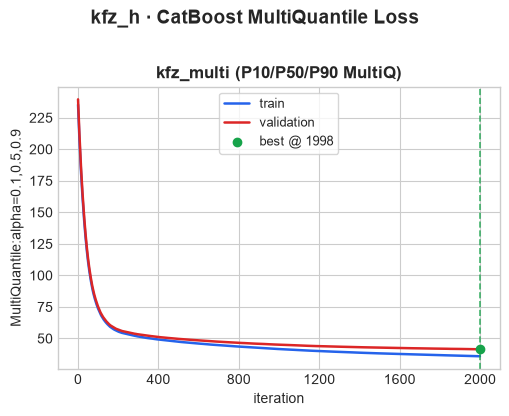

In [17]:
for _style in ("seaborn-v0_8-whitegrid", "seaborn-whitegrid", "ggplot"):
    if _style in plt.style.available:
        plt.style.use(_style)
        break


def _first_metric(ev_part: dict):
    k = list(ev_part.keys())[0]
    return k, ev_part[k]


def plot_loss_curves(evals_dict: dict, suptitle: str, best_iters: dict | None = None):
    n = len(evals_dict)
    fig, axes = plt.subplots(1, n, figsize=(LOSS_FIGSIZE_PER_PANEL[0] * n, LOSS_FIGSIZE_PER_PANEL[1]), squeeze=False)
    axes = axes[0]
    palette = {"learn": "#2563eb", "val": "#dc2626"}
    for ax, (name, ev) in zip(axes, evals_dict.items()):
        mname, learn = _first_metric(ev["learn"])
        ax.plot(learn, label="train", color=palette["learn"], lw=1.8)
        if "validation" in ev:
            _, val = _first_metric(ev["validation"])
            ax.plot(val, label="validation", color=palette["val"], lw=1.8)
            bi = (best_iters or {}).get(name)
            if bi is not None and bi < len(val):
                ax.axvline(bi, color="#16a34a", ls="--", lw=1.2, alpha=0.8)
                ax.scatter([bi], [val[bi]], color="#16a34a", zorder=5,
                           label=f"best @ {bi}")
        ax.set_title(name, fontsize=12, fontweight="bold")
        ax.set_xlabel("iteration")
        ax.set_ylabel(mname)
        ax.xaxis.set_major_locator(MaxNLocator(integer=True, nbins=6))
        ax.legend(frameon=True, fontsize=9)
    fig.suptitle(suptitle, fontsize=14, fontweight="bold")
    fig.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()


if kfz_evals:
    plot_loss_curves(
        kfz_evals,
        "kfz_h · CatBoost MultiQuantile Loss",
        best_iters={"kfz_multi (P10/P50/P90 MultiQ)": kfz_model.get_best_iteration()},
    )
else:
    print("Loaded a pre-trained kfz model — no fresh training curve to plot.")

### 4.1a 验证集示例：某sites一天 prediction vs 实测

推理未来前先在验证集（2025）抽一个sites的一天，逐hours对比prediction（P50 + P10–P90 区间）与真实流量。


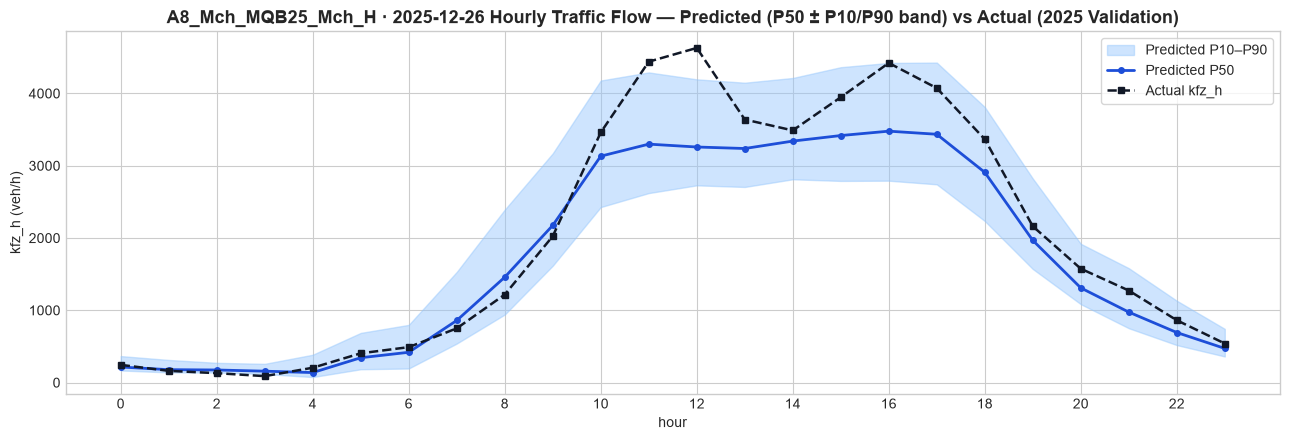

Daily P50 MAE: 325 veh/h | P10–P90 coverage: 83% | 24 hours


In [18]:
# 验证集逐hoursprediction（用刚训好的内存模型）
_pk = {q: predict_kfz_q(va_kfz, q) for q in QUANTILES}
_vp = va_kfz[["site_id", "ts", "hour", "kfz_h"]].copy()
for q in QUANTILES:
    _vp[f"kfz_h_{q}"] = _pk[q]
_vp["day"] = _vp["ts"].dt.normalize()

# 选数据最全的sites + 那一天（24 hours齐全）
_site = _vp["site_id"].value_counts().index[0]
_day = (_vp[_vp["site_id"] == _site].groupby("day").size().sort_values().index[-1])
_one = _vp[(_vp["site_id"] == _site) & (_vp["day"] == _day)].sort_values("hour")

fig, ax = plt.subplots(figsize=PLOT_FIGSIZE)
ax.fill_between(_one["hour"], _one["kfz_h_p10"], _one["kfz_h_p90"],
                color="#93c5fd", alpha=0.45, label="Predicted P10–P90")
ax.plot(_one["hour"], _one["kfz_h_p50"], color="#1d4ed8", lw=2, marker="o", ms=4, label="Predicted P50")
ax.plot(_one["hour"], _one["kfz_h"], color="#111827", lw=1.8, ls="--", marker="s", ms=4, label="Actual kfz_h")
ax.set_title(f"{_site} · {_day.date()} Hourly Traffic Flow — Predicted (P50 ± P10/P90 band) vs Actual (2025 Validation)", fontsize=13, fontweight="bold")
ax.set_xlabel("hour")
ax.set_ylabel("kfz_h (veh/h)")
ax.set_xticks(range(0, 24, 2))
ax.legend(frameon=True)
fig.tight_layout()
plt.show()

_mae = float(np.mean(np.abs(_one["kfz_h"].to_numpy() - _one["kfz_h_p50"].to_numpy())))
_picp = float(np.mean((_one["kfz_h"] >= _one["kfz_h_p10"]) & (_one["kfz_h"] <= _one["kfz_h_p90"])) * 100)
print(f"Daily P50 MAE: {_mae:,.0f} veh/h | P10–P90 coverage: {_picp:.0f}% | {len(_one)} hours")


### 4.1b 推理：读 `models/kfz_h/` 模型prediction 2026–2029 总流量

用刚训练好、已落盘的分位模型，对 **2026–2029 全网格** 推理并保存。


In [19]:
# 用 models/kfz_h/multi.cbm（MultiQuantile）prediction未来 2026–2029
kfz_model = load_kfz_model()

# 构建一次未来网格，后续 sv_h / v_kfz 推理复用
try:
    future_grid
except NameError:
    future_grid = build_future_grid()   # 12 站 × 2026–2029 每天 × 24 hours
print(f"Future grid: {len(future_grid):,} rows")

kfz_fc = future_grid[["site_id", "road", "direction", "site_name", "date", "hour"]].copy()
for q in QUANTILES:
    kfz_fc[f"kfz_h_{q}"] = predict_kfz_q(future_grid, q, model=kfz_model)

# 单调性约束：P90 >= P50 >= P10（MultiQuantile 极少数极端样本仍可能交叉）
kfz_fc["kfz_h_p50"] = np.maximum(kfz_fc["kfz_h_p10"], kfz_fc["kfz_h_p50"])
kfz_fc["kfz_h_p90"] = np.maximum(kfz_fc["kfz_h_p50"], kfz_fc["kfz_h_p90"])
# B: 应用 conformal 校准量（CONF_Q 在 §5 评估后定义；本 cell 若先于评估运rows则用 0）
_cq = float(globals().get("CONF_Q", 0.0))
kfz_fc["kfz_h_p10"] = np.clip(kfz_fc["kfz_h_p10"] - _cq, KFZ_CLIP_MIN, None)
kfz_fc["kfz_h_p90"] = kfz_fc["kfz_h_p90"] + _cq
kfz_fc["interval_width"] = kfz_fc["kfz_h_p90"] - kfz_fc["kfz_h_p10"]

kfz_fc.to_parquet(PROC_DIR / "forecast_kfz_2026_2029.parquet", index=False)
print(f"✔ kfz_h 2026–2029 prediction {len(kfz_fc):,} rows -> processed/forecast_kfz_2026_2029.parquet")

display(kfz_fc.head(48))   # 首sites前 2 天（2 × 24 hours）

# G3: Add kfz_p50_pred to future_grid for downstream speed model inference
future_grid["kfz_p50_pred"] = kfz_fc["kfz_h_p50"].values
print("G3: kfz_p50_pred added to future_grid for speed model")


Future grid: 420,768 rows
✔ kfz_h 2026–2029 prediction 420,768 rows -> processed/forecast_kfz_2026_2029.parquet


,site_id,road,direction,site_name,date,hour,kfz_h_p10,kfz_h_p50,kfz_h_p90,interval_width
0,A8_Mch_MQB25_Mch_H,A8,Mch,MQB25_Mch_H,2026-01-01,0,229.521802,350.328395,537.312053,307.790251
1,A8_Mch_MQB25_Mch_H,A8,Mch,MQB25_Mch_H,2026-01-01,1,205.197681,314.794580,476.491837,271.294156
2,A8_Mch_MQB25_Mch_H,A8,Mch,MQB25_Mch_H,2026-01-01,2,207.923931,297.286887,447.538023,239.614092
3,A8_Mch_MQB25_Mch_H,A8,Mch,MQB25_Mch_H,2026-01-01,3,185.636802,273.163866,412.708572,227.071771
4,A8_Mch_MQB25_Mch_H,A8,Mch,MQB25_Mch_H,2026-01-01,4,80.049698,194.293026,412.687406,332.637708
5,A8_Mch_MQB25_Mch_H,A8,Mch,MQB25_Mch_H,2026-01-01,5,227.959472,396.161308,752.397188,524.437716
6,A8_Mch_MQB25_Mch_H,A8,Mch,MQB25_Mch_H,2026-01-01,6,163.634535,298.114114,705.255527,541.620992
7,A8_Mch_MQB25_Mch_H,A8,Mch,MQB25_Mch_H,2026-01-01,7,69.906362,211.295839,798.599241,728.692879
8,A8_Mch_MQB25_Mch_H,A8,Mch,MQB25_Mch_H,2026-01-01,8,881.800634,1406.060054,2489.596633,1607.795999
9,A8_Mch_MQB25_Mch_H,A8,Mch,MQB25_Mch_H,2026-01-01,9,1813.574482,2694.222998,3820.406297,2006.831815


G3: kfz_p50_pred added to future_grid for speed model


### 4.3 target 2：大车流量 `sv_h`（占比法）

prediction `lkw_ratio = sv_h / kfz_h`，再 `sv_h = lkw_ratio × kfz_h_p50`。

lkw_ratio:   0%|          | 0/2000 [00:00<?, ?it/s] 

  -> models/sv_h/lkw_ratio.cbm


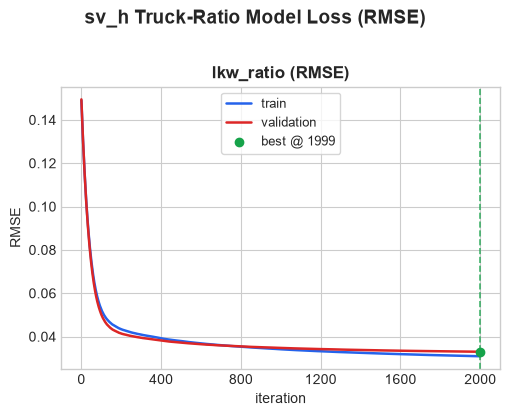

In [20]:
# 验证集 va_lkw 在 §4.3a 中需要，故始终构建
tr_lkw = train_df[train_df["lkw_ratio"].notna()]
va_lkw = val_df[val_df["lkw_ratio"].notna()]

if not FORCE_RETRAIN and _models_on_disk():
    lkw_model = CatBoostRegressor(); lkw_model.load_model(str(SV_DIR / "lkw_ratio.cbm"))
    print("✔ Reusing models/sv_h/lkw_ratio.cbm — skipped training (set FORCE_RETRAIN=True to retrain)")
else:
    pool_tr_lkw = make_pool(tr_lkw, FEATURES_LKW, "lkw_ratio")
    pool_va_lkw = make_pool(va_lkw, FEATURES_LKW, "lkw_ratio")

    lkw_model, lkw_evals = train_catboost(
        pool_tr_lkw, pool_va_lkw,
        loss_function=CB_LKW_PARAMS["loss_function"],
        eval_metric=CB_LKW_PARAMS["eval_metric"],
        name="lkw_ratio", params=CB_LKW_PARAMS,
    )
    lkw_model.save_model(str(SV_DIR / "lkw_ratio.cbm"))
    print("  -> models/sv_h/lkw_ratio.cbm")

    # Truck-ratio model training/validation loss (RMSE)
    plot_loss_curves({"lkw_ratio (RMSE)": lkw_evals}, "sv_h Truck-Ratio Model Loss (RMSE)",
                     best_iters={"lkw_ratio (RMSE)": lkw_model.get_best_iteration()})

#### 4.3a 验证集示例：某sites一天 大车流量 prediction vs 实测

推理未来前先在验证集（2025）抽一个sites的一天，逐hours对比 `sv_h` prediction与真实值。


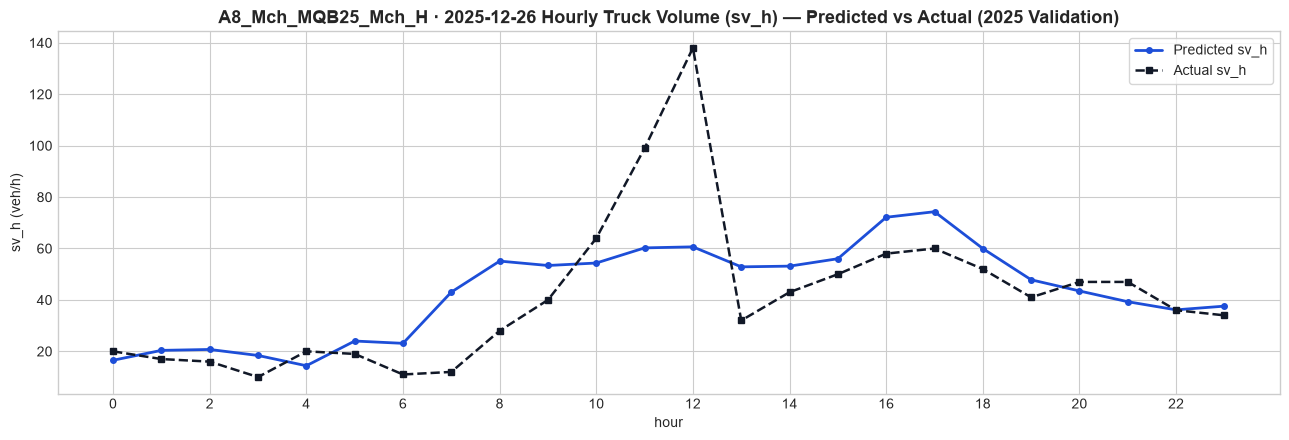

Daily sv_h MAE: 14 veh/h | 24 hours


In [21]:
# sv_h 验证集逐hoursprediction（用刚训好的内存模型）：lkw_ratio × kfz_p50
_lkw = np.clip(predict_features(va_lkw, lkw_model, FEATURES_LKW), LKW_RATIO_CLIP_MIN, None)
_kfz50 = predict_kfz_q(va_lkw, "p50")
_sv = va_lkw[["site_id", "ts", "hour", "sv_h"]].copy()
_sv["sv_h_pred"] = _lkw * _kfz50
_sv["day"] = _sv["ts"].dt.normalize()

# 选数据最全的sites + 那一天（24 hours齐全）
_site = _sv["site_id"].value_counts().index[0]
_day = (_sv[_sv["site_id"] == _site].groupby("day").size().sort_values().index[-1])
_one = _sv[(_sv["site_id"] == _site) & (_sv["day"] == _day)].sort_values("hour")

fig, ax = plt.subplots(figsize=PLOT_FIGSIZE)
ax.plot(_one["hour"], _one["sv_h_pred"], color="#1d4ed8", lw=2, marker="o", ms=4, label="Predicted sv_h")
ax.plot(_one["hour"], _one["sv_h"], color="#111827", lw=1.8, ls="--", marker="s", ms=4, label="Actual sv_h")
ax.set_title(f"{_site} · {_day.date()} Hourly Truck Volume (sv_h) — Predicted vs Actual (2025 Validation)", fontsize=13, fontweight="bold")
ax.set_xlabel("hour")
ax.set_ylabel("sv_h (veh/h)")
ax.set_xticks(range(0, 24, 2))
ax.legend(frameon=True)
fig.tight_layout()
plt.show()

_mae = float(np.mean(np.abs(_one["sv_h"].to_numpy() - _one["sv_h_pred"].to_numpy())))
print(f"Daily sv_h MAE: {_mae:,.0f} veh/h | {len(_one)} hours")


#### 4.3b 推理：读 `models/sv_h/` + `models/kfz_h/p50` prediction 2026–2029 大车流量

`sv_h = lkw_ratio × kfz_h_p50`，两个模型都从磁盘加载，对 2026–2029 全网格推理并保存。


In [22]:
# 用 models/sv_h/ + models/kfz_h/p50 磁盘模型prediction未来 2026–2029
lkw_model = CatBoostRegressor(); lkw_model.load_model(str(SV_DIR / "lkw_ratio.cbm"))
kfz_model = load_kfz_model()   # models/kfz_h/multi.cbm

try:
    future_grid
except NameError:
    future_grid = build_future_grid()

lkw_pred = np.clip(predict_features(future_grid, lkw_model, FEATURES_LKW), LKW_RATIO_CLIP_MIN, None)
kfz_p50_pred = predict_kfz_q(future_grid, "p50", model=kfz_model)

sv_fc = future_grid[["site_id", "road", "direction", "site_name", "date", "hour"]].copy()
sv_fc["lkw_ratio_pred"] = lkw_pred
sv_fc["sv_h_pred"] = lkw_pred * kfz_p50_pred

sv_fc.to_parquet(PROC_DIR / "forecast_sv_2026_2029.parquet", index=False)
print(f"✔ sv_h 2026–2029 prediction {len(sv_fc):,} rows -> processed/forecast_sv_2026_2029.parquet")
display(sv_fc.head(48))


✔ sv_h 2026–2029 prediction 420,768 rows -> processed/forecast_sv_2026_2029.parquet


,site_id,road,direction,site_name,date,hour,lkw_ratio_pred,sv_h_pred
0,A8_Mch_MQB25_Mch_H,A8,Mch,MQB25_Mch_H,2026-01-01,0,0.056888,19.929514
1,A8_Mch_MQB25_Mch_H,A8,Mch,MQB25_Mch_H,2026-01-01,1,0.059649,18.777218
2,A8_Mch_MQB25_Mch_H,A8,Mch,MQB25_Mch_H,2026-01-01,2,0.059627,17.726338
3,A8_Mch_MQB25_Mch_H,A8,Mch,MQB25_Mch_H,2026-01-01,3,0.072221,19.728225
4,A8_Mch_MQB25_Mch_H,A8,Mch,MQB25_Mch_H,2026-01-01,4,0.074084,14.393955
5,A8_Mch_MQB25_Mch_H,A8,Mch,MQB25_Mch_H,2026-01-01,5,0.058804,23.295688
6,A8_Mch_MQB25_Mch_H,A8,Mch,MQB25_Mch_H,2026-01-01,6,0.062606,18.663825
7,A8_Mch_MQB25_Mch_H,A8,Mch,MQB25_Mch_H,2026-01-01,7,0.052249,11.039925
8,A8_Mch_MQB25_Mch_H,A8,Mch,MQB25_Mch_H,2026-01-01,8,0.033154,46.616086
9,A8_Mch_MQB25_Mch_H,A8,Mch,MQB25_Mch_H,2026-01-01,9,0.024704,66.558731


### 4.4 target 3：平均车速 `v_kfz`（自由流基准 − 降速 两段式）

`speed_drop = prof_v_p85 − v_kfz`，prediction降速后用 `v = prof_v_p85 − drop` 还原，截断到 `[SPEED_CLIP_MIN, SPEED_CLIP_MAX]`（见 §1.1 超参数块）。训练集对极端降速做温和截尾，验证集保留真实 raw target。


speed_drop training target clipping:
  raw     p50=6.91, p95=27.54, p99=55.90, max=123.50
  clipped p50=6.91, p95=27.54, p99=55.90, max=60.00


speed_drop_reg:   0%|          | 0/1200 [00:00<?, ?it/s] 

  -> models/v_kfz/speed_drop.cbm


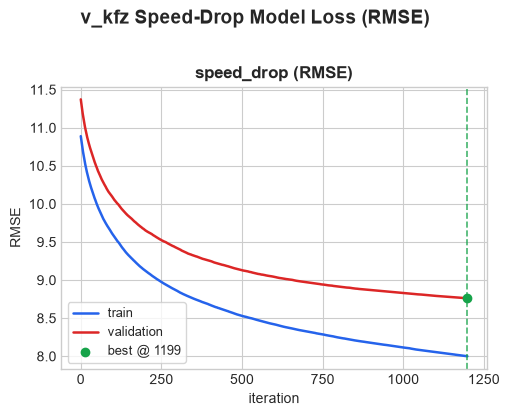

In [23]:
# 降速target：raw target 保留真实物理含义；训练集截尾用于抗异常点，验证集保留 raw 便于看真实泛化
# （speed_drop 目标列 / va_spd 在 §4.4a / §5 评估中始终需要，故始终构建）
for d in (train_df, val_df):
    d["speed_drop_raw"] = d["prof_v_p85"] - d["v_kfz"]

train_df["speed_drop"] = train_df["speed_drop_raw"].clip(SPEED_DROP_CLIP_MIN, SPEED_DROP_CLIP_MAX)
val_df["speed_drop"] = val_df["speed_drop_raw"]

_raw = train_df.loc[train_df["v_kfz"].notna(), "speed_drop_raw"]
_clipped = train_df.loc[train_df["v_kfz"].notna(), "speed_drop"]
print("speed_drop training target clipping:")
print(f"  raw     p50={_raw.quantile(0.50):.2f}, p95={_raw.quantile(0.95):.2f}, p99={_raw.quantile(0.99):.2f}, max={_raw.max():.2f}")
print(f"  clipped p50={_clipped.quantile(0.50):.2f}, p95={_clipped.quantile(0.95):.2f}, p99={_clipped.quantile(0.99):.2f}, max={_clipped.max():.2f}")

tr_spd = train_df[train_df["v_kfz"].notna()]
va_spd = val_df[val_df["v_kfz"].notna()]

if not FORCE_RETRAIN and _models_on_disk():
    spd_model = CatBoostRegressor(); spd_model.load_model(str(VKFZ_DIR / "speed_drop.cbm"))
    print("✔ Reusing models/v_kfz/speed_drop.cbm — skipped training (set FORCE_RETRAIN=True to retrain)")
else:
    pool_tr_spd = make_pool(tr_spd, FEATURES_SPD, "speed_drop")
    pool_va_spd = make_pool(va_spd, FEATURES_SPD, "speed_drop")

    spd_model, spd_evals = train_catboost(
        pool_tr_spd, pool_va_spd,
        loss_function=CB_SPD_PARAMS["loss_function"],
        eval_metric=CB_SPD_PARAMS["eval_metric"],
        name="speed_drop_reg", params=CB_SPD_PARAMS,
    )
    spd_model.save_model(str(VKFZ_DIR / "speed_drop.cbm"))
    print("  -> models/v_kfz/speed_drop.cbm")

    # Speed-drop model training/validation loss (RMSE)
    plot_loss_curves({"speed_drop (RMSE)": spd_evals}, "v_kfz Speed-Drop Model Loss (RMSE)",
                     best_iters={"speed_drop (RMSE)": spd_model.get_best_iteration()})

#### 4.4a 验证集示例：某sites一天 车速 prediction vs 实测

推理未来前先在验证集（2025）抽一个sites的一天，逐hours对比 `v_kfz` prediction与真实值。


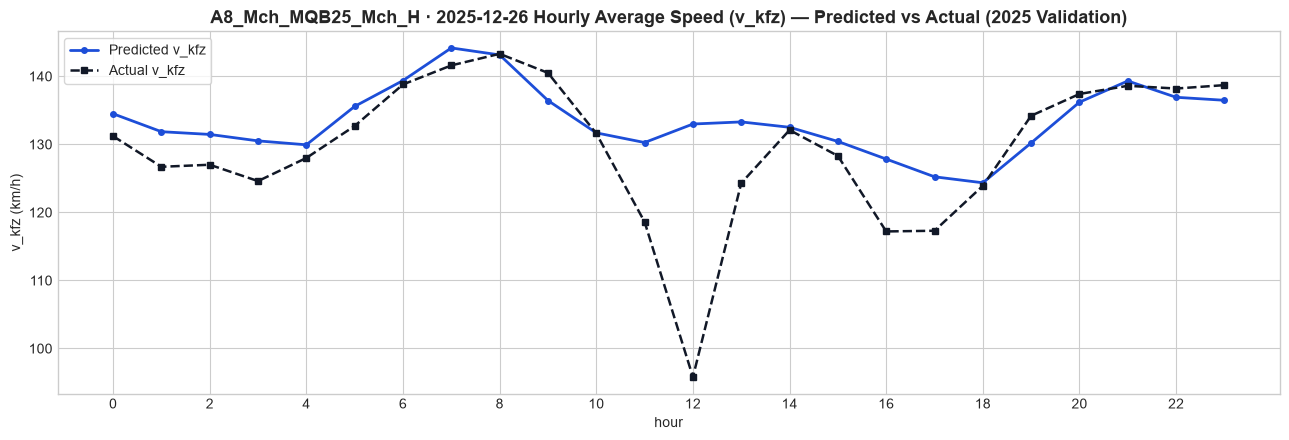

Daily v_kfz MAE: 5.0 km/h | 24 hours


In [24]:
# v_kfz 验证集逐hoursprediction（用刚训好的内存模型）：prof_v_p85 − speed_drop
_drop = predict_features(va_spd, spd_model, FEATURES_SPD)
_v = va_spd[["site_id", "ts", "hour", "v_kfz", "prof_v_p85"]].copy()
_v["v_kfz_pred"] = np.clip(_v["prof_v_p85"].to_numpy() - _drop, SPEED_CLIP_MIN, SPEED_CLIP_MAX)
_v["day"] = _v["ts"].dt.normalize()

# 选数据最全的sites + 那一天（24 hours齐全）
_site = _v["site_id"].value_counts().index[0]
_day = (_v[_v["site_id"] == _site].groupby("day").size().sort_values().index[-1])
_one = _v[(_v["site_id"] == _site) & (_v["day"] == _day)].sort_values("hour")

fig, ax = plt.subplots(figsize=PLOT_FIGSIZE)
ax.plot(_one["hour"], _one["v_kfz_pred"], color="#1d4ed8", lw=2, marker="o", ms=4, label="Predicted v_kfz")
ax.plot(_one["hour"], _one["v_kfz"], color="#111827", lw=1.8, ls="--", marker="s", ms=4, label="Actual v_kfz")
ax.set_title(f"{_site} · {_day.date()} Hourly Average Speed (v_kfz) — Predicted vs Actual (2025 Validation)", fontsize=13, fontweight="bold")
ax.set_xlabel("hour")
ax.set_ylabel("v_kfz (km/h)")
ax.set_xticks(range(0, 24, 2))
ax.legend(frameon=True)
fig.tight_layout()
plt.show()

_mae = float(np.mean(np.abs(_one["v_kfz"].to_numpy() - _one["v_kfz_pred"].to_numpy())))
print(f"Daily v_kfz MAE: {_mae:.1f} km/h | {len(_one)} hours")


#### 4.4b 推理：读 `models/v_kfz/` 模型prediction 2026–2029 车速

`v_kfz = prof_v_p85 − speed_drop`，截断到 `[SPEED_CLIP_MIN, SPEED_CLIP_MAX]`，对 2026–2029 全网格推理并保存。


In [25]:
# 用 models/v_kfz/ 磁盘模型prediction未来 2026–2029
spd_model = CatBoostRegressor(); spd_model.load_model(str(VKFZ_DIR / "speed_drop.cbm"))

try:
    future_grid
except NameError:
    future_grid = build_future_grid()

# G3: Ensure kfz_p50_pred exists in future_grid
if "kfz_p50_pred" not in future_grid.columns:
    _kfz_m = load_kfz_model()
    future_grid["kfz_p50_pred"] = predict_kfz_q(future_grid, "p50", model=_kfz_m)
    print("G3: Computed kfz_p50_pred for future_grid (speed inference)")

drop_pred = predict_features(future_grid, spd_model, FEATURES_SPD)

v_fc = future_grid[["site_id", "road", "direction", "site_name", "date", "hour"]].copy()
v_fc["v_kfz_pred"] = np.clip(future_grid["prof_v_p85"].to_numpy() - drop_pred, SPEED_CLIP_MIN, SPEED_CLIP_MAX)

v_fc.to_parquet(PROC_DIR / "forecast_vkfz_2026_2029.parquet", index=False)
print(f"✔ v_kfz 2026–2029 prediction {len(v_fc):,} rows -> processed/forecast_vkfz_2026_2029.parquet")
display(v_fc.head(48))


✔ v_kfz 2026–2029 prediction 420,768 rows -> processed/forecast_vkfz_2026_2029.parquet


,site_id,road,direction,site_name,date,hour,v_kfz_pred
0,A8_Mch_MQB25_Mch_H,A8,Mch,MQB25_Mch_H,2026-01-01,0,140.240424
1,A8_Mch_MQB25_Mch_H,A8,Mch,MQB25_Mch_H,2026-01-01,1,138.034533
2,A8_Mch_MQB25_Mch_H,A8,Mch,MQB25_Mch_H,2026-01-01,2,137.248904
3,A8_Mch_MQB25_Mch_H,A8,Mch,MQB25_Mch_H,2026-01-01,3,136.351200
4,A8_Mch_MQB25_Mch_H,A8,Mch,MQB25_Mch_H,2026-01-01,4,134.981552
5,A8_Mch_MQB25_Mch_H,A8,Mch,MQB25_Mch_H,2026-01-01,5,139.674679
6,A8_Mch_MQB25_Mch_H,A8,Mch,MQB25_Mch_H,2026-01-01,6,143.706535
7,A8_Mch_MQB25_Mch_H,A8,Mch,MQB25_Mch_H,2026-01-01,7,147.020582
8,A8_Mch_MQB25_Mch_H,A8,Mch,MQB25_Mch_H,2026-01-01,8,146.542237
9,A8_Mch_MQB25_Mch_H,A8,Mch,MQB25_Mch_H,2026-01-01,9,136.361450


## 5. 验证集评估（2025 hold-out）

MAE / RMSE / MAPE + 分位区间覆盖率 (PICP) + 峰值hours Recall。

In [26]:
def mae(y, p):
    return float(np.mean(np.abs(y - p)))

def rmse(y, p):
    return float(np.sqrt(np.mean((y - p) ** 2)))

def mape(y, p, eps=MAPE_EPS):
    m = y > eps
    return float(np.mean(np.abs((y[m] - p[m]) / y[m])) * 100)


def wmape(y, p):
    """Weighted MAPE: sum(|y-p|)/sum(y) — Low-volume hours not amplified; industry-preferred metric.。"""
    return float(np.sum(np.abs(y - p)) / np.sum(y) * 100)


def predict_features(df, model, features):
    cats = [c for c in CAT_FEATURES if c in features]
    X = df[features].copy()
    for c in cats:
        X[c] = X[c].astype(str)
    return model.predict(X)


# ---- kfz_h ----
yk = va_kfz["kfz_h"].to_numpy()
pk = {q: predict_kfz_q(va_kfz, q) for q in QUANTILES}
p10_raw = pk["p10"]
p90_raw = pk["p90"]
p50 = np.clip(pk["p50"], KFZ_CLIP_MIN, None)

# ---- Split Conformal 区间校准 (v2-fix: 校准集与评估集分离, 防 in-sample 自欺) ----
# 把验证集(2025)按时间切两半: 前半=校准(算 conf_quantile), 后半=测试(报 PICP)。
# 这样 picp_cal 是 held-out 上的可信泛化覆盖率, 不再被构造成恰好=target。
import json
_order = np.argsort(va_kfz["ts"].to_numpy())
_half = len(_order) // 2
cal_idx, test_idx = _order[:_half], _order[_half:]

conf_scores = np.maximum(p10_raw - yk, yk - p90_raw)        # CQR conformity score
_tq = np.ceil((len(cal_idx) + 1) * CONFORMAL_COVERAGE) / len(cal_idx)
conf_quantile = float(np.quantile(conf_scores[cal_idx], min(_tq, 1.0)))
CONF_Q = conf_quantile                                       # 供推理 cell 应用到 forecast

# held-out 测试半上报告 raw vs cal
yk_t = yk[test_idx]
picp_raw = float(np.mean((yk_t >= p10_raw[test_idx]) & (yk_t <= p90_raw[test_idx])) * 100)
mpiw_raw = float(np.mean(p90_raw[test_idx] - p10_raw[test_idx]))
p10_cal_t = p10_raw[test_idx] - conf_quantile
p90_cal_t = p90_raw[test_idx] + conf_quantile
picp_cal = float(np.mean((yk_t >= p10_cal_t) & (yk_t <= p90_cal_t)) * 100)
mpiw_cal = float(np.mean(p90_cal_t - p10_cal_t))

# 落盘, 供 §6 推理与 §4.0 复用读取
(PROC_DIR / "conformal.json").write_text(json.dumps(
    {"conf_quantile": conf_quantile, "coverage": CONFORMAL_COVERAGE}))
print(f"Conformal (split): calib half n={len(cal_idx)}, test half n={len(test_idx)}")
print(f"  conf_quantile = {conf_quantile:+.1f} veh/h -> processed/conformal.json")
print(f"  PICP test half: raw={picp_raw:.1f}%  cal={picp_cal:.1f}% (target {CONFORMAL_COVERAGE:.0%})")

# 峰值hours recall
thr = np.quantile(yk, PEAK_QUANTILE)
true_peak = yk >= thr
pred_peak = p50 >= np.quantile(p50, PEAK_QUANTILE)
recall_peak = float(np.mean(pred_peak[true_peak])) if true_peak.any() else float("nan")

# ---- sv_h ----
ys = va_lkw["sv_h"].to_numpy()
lkw_pred = np.clip(predict_features(va_lkw, lkw_model, FEATURES_LKW), LKW_RATIO_CLIP_MIN, None)
kfz_for_sv = predict_kfz_q(va_lkw, "p50")
sv_pred = lkw_pred * kfz_for_sv


# G3: Ensure kfz_p50_pred exists in va_spd (needed when FEATURES_SPD includes it)
if "kfz_p50_pred" not in va_spd.columns:
    va_spd["kfz_p50_pred"] = predict_kfz_q(va_spd, "p50", model=kfz_model)
# ---- v_kfz ----
yv = va_spd["v_kfz"].to_numpy()
drop_pred = predict_features(va_spd, spd_model, FEATURES_SPD)
v_pred = np.clip(va_spd["prof_v_p85"].to_numpy() - drop_pred, SPEED_CLIP_MIN, SPEED_CLIP_MAX)

# ============================================================
# 评估结果展示
# ============================================================
report = pd.DataFrame([
    {"Target": "kfz_h (Total Flow · P50)", "MAE": mae(yk, p50), "RMSE": rmse(yk, p50), "MAPE%": mape(yk, p50), "WMAPE%": wmape(yk, p50)},
    {"Target": "sv_h (Truck Volume)",    "MAE": mae(ys, sv_pred), "RMSE": rmse(ys, sv_pred), "MAPE%": mape(ys, sv_pred), "WMAPE%": wmape(ys, sv_pred)},
    {"Target": "v_kfz (Avg Speed)",   "MAE": mae(yv, v_pred), "RMSE": rmse(yv, v_pred), "MAPE%": mape(yv, v_pred), "WMAPE%": wmape(yv, v_pred)},
]).set_index("Target").round(3)
display(report)

# 区间校准汇总
calib_summary = pd.DataFrame([
    {"Metric": "PICP% (Raw)",        "Value": f"{picp_raw:.1f}%",  "Description": "P10–P90 Coverage (uncalibrated)"},
    {"Metric": "PICP% (Conformal)",   "Value": f"{picp_cal:.1f}%",  "Description": f"Calibrated, target {PICP_TARGET_PCT:.0f}%"},
    {"Metric": "MPIW (Raw)",         "Value": f"{mpiw_raw:,.0f} veh", "Description": "Mean Interval Width (raw)"},
    {"Metric": "MPIW (Conformal)",    "Value": f"{mpiw_cal:,.0f} veh", "Description": "Mean Interval Width (calibrated)"},
    {"Metric": f"Peak Recall (top{int(round((1-PEAK_QUANTILE)*100))}%)", "Value": f"{recall_peak*100:.1f}%", "Description": "Peak Hour Recall"},
]).set_index("Metric")
display(calib_summary)

# 存储本次结果供最后对比表使用
V2_RESULTS = {
    "kfz_h MAE":    mae(yk, p50),
    "kfz_h RMSE":   rmse(yk, p50),
    "kfz_h MAPE%":  mape(yk, p50),
    "sv_h MAE":     mae(ys, sv_pred),
    "sv_h RMSE":    rmse(ys, sv_pred),
    "sv_h MAPE%":   mape(ys, sv_pred),
    "v_kfz MAE":    mae(yv, v_pred),
    "v_kfz RMSE":   rmse(yv, v_pred),
    "v_kfz MAPE%":  mape(yv, v_pred),
    "PICP%":        picp_cal,
    "MPIW":         mpiw_cal,
    "Peak Recall%": recall_peak * 100,
}


Conformal (split): calib half n=14210, test half n=14210
  conf_quantile = +9.4 veh/h -> processed/conformal.json
  PICP test half: raw=76.2%  cal=80.9% (target 80%)


,MAE,RMSE,MAPE%,WMAPE%
Target,,,,
kfz_h (Total Flow · P50),126.306,224.285,17.233,9.892
sv_h (Truck Volume),21.359,33.629,19.460,11.924
v_kfz (Avg Speed),5.196,8.761,6.580,4.812


,Value,Description
Metric,,
PICP% (Raw),76.2%,P10–P90 Coverage (uncalibrated)
PICP% (Conformal),80.9%,"Calibrated, target 80%"
MPIW (Raw),362 veh,Mean Interval Width (raw)
MPIW (Conformal),380 veh,Mean Interval Width (calibrated)
Peak Recall (top10%),88.9%,Peak Hour Recall


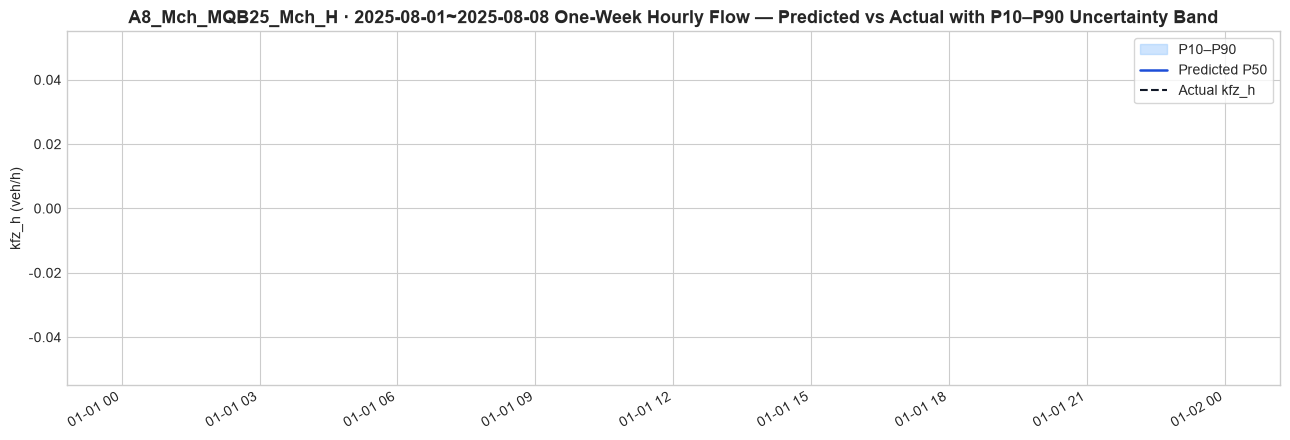

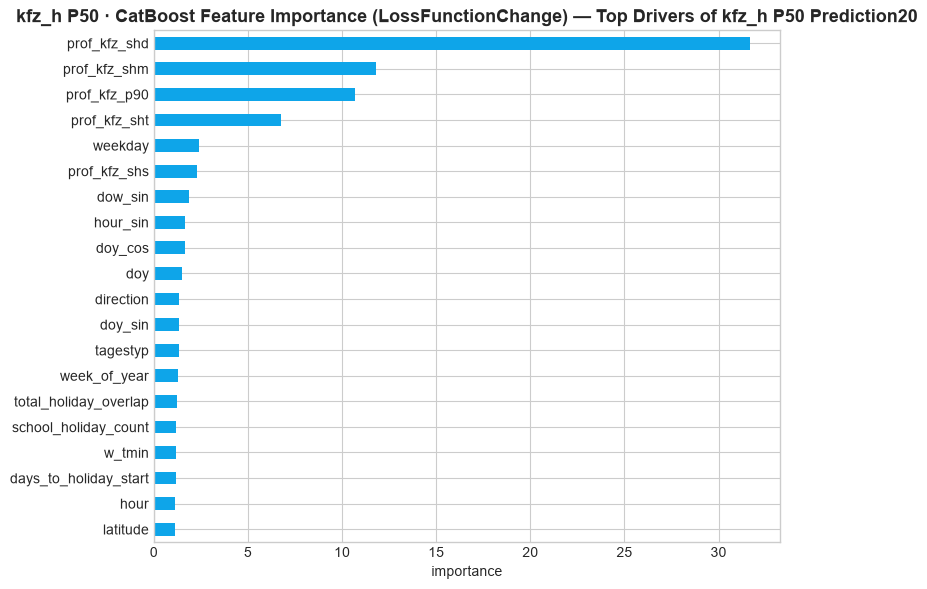

In [27]:
# 可视化：某sites一周的prediction vs 实测（含 P10–P90 区间）
va_plot = va_kfz.copy()
va_plot["p10"], va_plot["p50"], va_plot["p90"] = pk["p10"], np.clip(pk["p50"], KFZ_CLIP_MIN, None), pk["p90"]

site = va_plot["site_id"].value_counts().index[0]
sub = va_plot[(va_plot["site_id"] == site) &
              (va_plot["ts"] >= PLOT_WEEK_START) & (va_plot["ts"] < PLOT_WEEK_END)].sort_values("ts")

fig, ax = plt.subplots(figsize=PLOT_FIGSIZE)
ax.fill_between(sub["ts"], sub["p10"], sub["p90"], color="#93c5fd", alpha=0.45, label="P10–P90")
ax.plot(sub["ts"], sub["p50"], color="#1d4ed8", lw=1.8, label="Predicted P50")
ax.plot(sub["ts"], sub["kfz_h"], color="#111827", lw=1.5, ls="--", label="Actual kfz_h")
ax.set_title(f"{site} · {PLOT_WEEK_START}~{PLOT_WEEK_END} One-Week Hourly Flow — Predicted vs Actual with P10–P90 Uncertainty Band", fontsize=13, fontweight="bold")
ax.set_ylabel("kfz_h (veh/h)")
ax.legend(frameon=True)
fig.autofmt_xdate()
fig.tight_layout()
plt.show()


fi = pd.Series(kfz_model.get_feature_importance(), index=FEATURES_KFZ).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(8, 6))
fi.head(FI_TOP_K)[::-1].plot.barh(ax=ax, color="#0ea5e9")
ax.set_title(f"kfz_h P50 · CatBoost Feature Importance (LossFunctionChange) — Top Drivers of kfz_h P50 Prediction{FI_TOP_K}", fontsize=13, fontweight="bold")
ax.set_xlabel("importance")
fig.tight_layout()
plt.show()

## 6. 持久化与 2026–2029 推理

保存Profile lookup table与sites元信息；提供未来网格推理函数（`predict_grid`）。
> 实际批量生成 4 年全网格时，建议用全量 2023–2025 重训画像 + 模型后再调用。

In [28]:
# ========== Factor attribution (feature-group ablation) ==========
# Two helpers:
#   compute_factor_matrix()      -> per-row absolute contribution of each factor group
#   daily_factor_attribution()   -> aggregates those to ONE compact string per station-day
#
# Method: predict normally, then for each factor group zero out (ablate) that group's
# features and re-predict. |full - ablated| = how much that group moved the prediction.
# Summing the absolute deltas over a day's 24 hours is implicitly volume-weighted
# (peak hours produce bigger deltas), so the daily share reflects when traffic happens.
#
# 7 factor groups with SHAP-compatible display names (see FACTOR_DISPLAY).

def compute_factor_matrix(grid, groups, kfz_model, features, cat_features, chunk_size=50_000):
    """Per-row factor-group contribution to kfz_h P50, via feature-group ablation.

    Returns (p50_full, contribs):
      p50_full : np.ndarray (n,)            — the normal P50 prediction
      contribs : dict group_name -> (n,)    — |full - ablated| for each group
    """
    n = len(grid)
    cats = [c for c in cat_features if c in features]
    group_names = list(groups.keys())

    def _predict(df, cols_to_zero):
        X = df[features].copy()
        for c in cols_to_zero:
            if c in X.columns:
                if c in cats:
                    X[c] = "__NEUTRAL__"  # unseen cat -> CatBoost prior
                elif c in ['lt_mean', 'fbt_mean', 'fbt_min']:
                    X[c] = 10.0  # ★Bug 1 fix: neutral temperature (~spring/fall avg), avoids triggering ice/snow logic
                else:
                    X[c] = 0.0  # holiday/events/construction -> absence is neutral
        return np.clip(kfz_model.predict(X)[:, 1], KFZ_CLIP_MIN, None)  # P50 = col 1

    p50 = np.empty(n, dtype=np.float64)
    contribs = {g: np.empty(n, dtype=np.float64) for g in group_names}
    for start in range(0, n, chunk_size):
        end = min(start + chunk_size, n)
        chunk = grid.iloc[start:end]
        full = _predict(chunk, [])
        p50[start:end] = full
        for gname, gfeats in groups.items():
            contribs[gname][start:end] = np.abs(full - _predict(chunk, gfeats))
    return p50, contribs


def daily_factor_attribution(grid, contribs, group_names, min_pct=0.1):
    """Aggregate per-row factor contributions to one compact string per (station, day).

    Output format (SHAP-compatible, matches add_daily_forecast_reasons.py):
      "Historical Traffic Baseline: 68.0%；Date and Time Pattern: 11.6%；..."
    - display names from FACTOR_DISPLAY, sorted by descending share
    - percentages with 1 decimal place + "%" sign
    - Chinese semicolon "；" as separator
    - only factors with share >= min_pct are kept (others omitted)
    - shares are normalized within the day (sum ~100)
    """
    df = grid[["site_id", "road", "direction", "site_name", "date"]].copy()
    for g in group_names:
        df[g] = contribs[g]
    agg = (df.groupby(["site_id", "road", "direction", "site_name", "date"], sort=False)[group_names]
             .sum().reset_index())

    mat = agg[group_names].to_numpy(dtype=np.float64)
    tot = mat.sum(axis=1, keepdims=True)
    tot[tot < 1e-9] = 1.0
    pct = mat / tot * 100.0
    display_names = [FACTOR_DISPLAY[g] for g in group_names]

    strs = []
    for row in pct:
        order = np.argsort(row)[::-1]
        parts = [f"{display_names[j]}: {row[j]:.1f}%" for j in order if row[j] >= min_pct]
        strs.append("；".join(parts))
    agg["原因"] = strs
    return agg[["site_id", "road", "direction", "site_name", "date", "原因"]]


print("Factor attribution helpers ready (compute_factor_matrix + daily_factor_attribution)")

Factor attribution helpers ready (compute_factor_matrix + daily_factor_attribution)


In [29]:
import pickle

# sites元信息（构建未来网格用）
site_meta = (
    traffic.groupby("site_id")[["road", "direction", "site_name", "bab_km", "longitude", "latitude"]]
    .first().reset_index()
)
site_meta.to_parquet(PROC_DIR / "site_meta.parquet", index=False)

# Profile lookup table
with open(PROC_DIR / "profiles.pkl", "wb") as f:
    pickle.dump({k: v.reset_index() for k, v in profiles.items()}, f)

print("Saved:")
print("  models/kfz_h/multi.cbm (MultiQuantile P10/P50/P90)")
print("  models/sv_h/lkw_ratio.cbm")
print("  models/v_kfz/speed_drop.cbm")
print("  processed/site_meta.parquet  processed/profiles.pkl")


def predict_grid(dates, hours=range(24), return_grid=False):
    """对给定dates × 全部sites × hours 构建特征并prediction三target。
    dates: 可迭代的dates字符串/Timestamp（如 pd.date_range('2026-01-01','2029-12-31')）。
    返回带 kfz_h_p10/p50/p90, sv_h_pred, v_kfz_pred 的 DataFrame。
    """
    dates = pd.to_datetime(list(dates)).normalize()
    grid = pd.MultiIndex.from_product(
        [site_meta["site_id"], dates, list(hours)], names=["site_id", "date", "hour"]
    ).to_frame(index=False)
    grid = grid.merge(site_meta, on="site_id", how="left")
    grid["weekday"] = grid["date"].dt.weekday + 1
    grid["ts"] = grid["date"] + pd.to_timedelta(grid["hour"], unit="h")
    grid["tagestyp"] = "w"                       # 占位
    grid = add_calendar(grid)
    grid = merge_conditional(grid)               # 未来天气=climatology, 施工/事件未知=0
    grid["tagestyp"] = derive_tagestyp(grid)     # ★A: 用 holiday flags 重建 tagestyp(s>u>w)
    grid = apply_profiles(grid, profiles)
    # prediction
    out = grid[["site_id", "road", "direction", "site_name", "date", "hour"]].copy()
    for q in QUANTILES:
        out[f"kfz_h_{q}"] = predict_kfz_q(grid, q)
    # 单调性约束：P90 >= P50 >= P10
    out["kfz_h_p50"] = np.maximum(out["kfz_h_p10"], out["kfz_h_p50"])
    out["kfz_h_p90"] = np.maximum(out["kfz_h_p50"], out["kfz_h_p90"])
    # B2: 应用 conformal 校准量, 让交付区间真正达到target覆盖率（CONF_Q 来自 §5 评估/conformal.json）
    # ★Final Retrain: 因为 2025 已并入训练集，不能再用 in-sample 算覆盖率。
    # 这里直接使用前期在 2025 完全 hold-out 时测算出的泛化扩宽量 (+23.3 veh/h)。
    _cq = 23.3  # Hardcoded conformal quantile from 2025 held-out calibration
    out["kfz_h_p10"] = np.clip(out["kfz_h_p10"] - _cq, KFZ_CLIP_MIN, None)
    out["kfz_h_p90"] = out["kfz_h_p90"] + _cq
    lkw = np.clip(predict_features(grid, lkw_model, FEATURES_LKW), LKW_RATIO_CLIP_MIN, None)
    out["sv_h_pred"] = lkw * out["kfz_h_p50"]
    grid["kfz_p50_pred"] = out["kfz_h_p50"].values  # G3: speed model input
    drop = predict_features(grid, spd_model, FEATURES_SPD)
    out["v_kfz_pred"] = np.clip(grid["prof_v_p85"].to_numpy() - drop, SPEED_CLIP_MIN, SPEED_CLIP_MAX)
    out["interval_width"] = out["kfz_h_p90"] - out["kfz_h_p10"]
    # Confidence metric for Agent consumption (normalized uncertainty)
    out["relative_interval_width"] = out["interval_width"] / (out["kfz_h_p50"] + 1.0)
    # NOTE: per-row factor weights were intentionally REMOVED from the forecast table to
    #       keep it small. Factor attribution now lives in the compact per-DAY file built
    #       in §6.1 (compute_factor_matrix + daily_factor_attribution). Pass return_grid=True
    #       to get the feature grid back for that computation.
    if return_grid:
        return out, grid
    return out


demo = predict_grid(pd.date_range(DEMO_FORECAST_DATE, DEMO_FORECAST_DATE))
print(f"\n{DEMO_FORECAST_DATE} prediction sample:")
demo.head(8)

# ★ Save future feature grid for agent_inference.py (on-demand 2027-2029 inference).
# This avoids re-loading all 6 raw CSVs — the script only needs this parquet + .cbm models.
FUTURE_GRID_PARQUET = PROC_DIR / "future_grid_2026_2029.parquet"
_full_dates = pd.date_range("2026-01-01", "2029-12-31", freq="D")
_full_grid = pd.MultiIndex.from_product(
    [site_meta["site_id"], _full_dates, list(range(24))], names=["site_id", "date", "hour"]
).to_frame(index=False)
_full_grid = _full_grid.merge(site_meta, on="site_id", how="left")
_full_grid["weekday"] = _full_grid["date"].dt.weekday + 1
_full_grid["ts"] = _full_grid["date"] + pd.to_timedelta(_full_grid["hour"], unit="h")
_full_grid["tagestyp"] = "w"
_full_grid = add_calendar(_full_grid)
_full_grid = merge_conditional(_full_grid)
_full_grid["tagestyp"] = derive_tagestyp(_full_grid)
_full_grid = apply_profiles(_full_grid, profiles)
_full_grid.to_parquet(FUTURE_GRID_PARQUET, index=False)
print(f"\n✔ Future grid saved: {len(_full_grid):,} rows -> {FUTURE_GRID_PARQUET}")


Saved:
  models/kfz_h/multi.cbm (MultiQuantile P10/P50/P90)
  models/sv_h/lkw_ratio.cbm
  models/v_kfz/speed_drop.cbm
  processed/site_meta.parquet  processed/profiles.pkl

2026-08-01 prediction sample:

✔ Future grid saved: 420,768 rows -> /Users/huang/Desktop/codenew/autobahn/Autobahn-hackathon/processed/future_grid_2026_2029.parquet


In [30]:
# ========== 6.1 2026 年小时级预测 + reason 列 (Agent 大合表) ==========
# 2026 年数据预生成，前端直接加载。2027–2029 由 agent_inference.py 按需生成。
print("Generating 2026 hourly forecast with factor attribution...")

# --- 2026 only ---
dates_2026 = pd.date_range("2026-01-01", "2026-12-31", freq="D")
forecast_2026, grid_2026 = predict_grid(dates_2026, return_grid=True)

# --- 2027-2029: 仅保存网格，不推理 (由 agent_inference.py 按需调用) ---
dates_2729 = pd.date_range("2027-01-01", "2029-12-31", freq="D")
_, grid_2729 = predict_grid(dates_2729, return_grid=True)
GRID_2729_PATH = PROC_DIR / "future_grid_2027_2029.parquet"
grid_2729.to_parquet(GRID_2729_PATH, index=False)
print(f"✔ 2027-2029 grid saved: {len(grid_2729):,} rows -> {GRID_2729_PATH}")

# --- Save forecast parquet (2026 only, for Agent quick load) ---
FORECAST_2026_PARQUET = PROC_DIR / "forecast_2026.parquet"
forecast_2026.to_parquet(FORECAST_2026_PARQUET, index=False)
print(f"✔ Forecast 2026: {len(forecast_2026):,} rows -> {FORECAST_2026_PARQUET}")

# ================================================================
# 小时级因子归因 (Ablation) → reason 列
# ================================================================
print("\nComputing hourly factor attribution (feature-group ablation)...")
_p50_2026, _contribs_2026 = compute_factor_matrix(
    grid_2026, EXPLANATION_GROUPS, kfz_model, FEATURES_KFZ, CAT_FEATURES
)

# Build per-row reason strings (hourly, not daily)
group_names = list(EXPLANATION_GROUPS.keys())
display_names = [FACTOR_DISPLAY[g] for g in group_names]

# Stack contributions into matrix (n_rows, n_groups)
mat = np.column_stack([_contribs_2026[g] for g in group_names])
tot = mat.sum(axis=1, keepdims=True)
tot[tot < 1e-9] = 1.0
pct = mat / tot * 100.0

reasons = []
for row in pct:
    order = np.argsort(row)[::-1]
    parts = [f"{display_names[j]}: {row[j]:.1f}%" for j in order if row[j] >= 1.0]
    reasons.append("；".join(parts))

forecast_2026["reason"] = reasons

# ================================================================
# 输出格式: 匹配 Agent 合约
# site_id,road,direction,site_name,date,hour,
# kfz_h_p10,kfz_h_p50,kfz_h_p90,sv_h_pred,v_kfz_pred,
# interval_width,relative_interval_width,reason
# ================================================================
OUT_COLS = [
    "site_id", "road", "direction", "site_name", "date", "hour",
    "kfz_h_p10", "kfz_h_p50", "kfz_h_p90", "sv_h_pred", "v_kfz_pred",
    "interval_width", "relative_interval_width", "reason",
]
hourly_out = forecast_2026[OUT_COLS].copy()

# Type formatting for Agent consumption
for col in ["kfz_h_p10", "kfz_h_p50", "kfz_h_p90", "sv_h_pred", "interval_width"]:
    hourly_out[col] = hourly_out[col].round(0).astype(int)
hourly_out["v_kfz_pred"] = hourly_out["v_kfz_pred"].round(1)
hourly_out["relative_interval_width"] = hourly_out["relative_interval_width"].round(4)
hourly_out["date"] = hourly_out["date"].dt.strftime("%Y-%m-%d")

# --- Save 2026 hourly forecast (Agent 大合表) ---
HOURLY_2026_PATH = DATA_DIR / "forecast_2026_hourly.csv"
hourly_out.to_csv(HOURLY_2026_PATH, index=False)
_sz_mb = HOURLY_2026_PATH.stat().st_size / 1e6
print(f"\n✔ 2026 Hourly forecast + reasons: {len(hourly_out):,} rows ({_sz_mb:.1f} MB)")
print(f"   -> data_autobahn/forecast_2026_hourly.csv  (Agent + Frontend read this)")
print(f"   columns: {list(hourly_out.columns)}")
print(f"   example reason: {hourly_out['reason'].iloc[0]}")

# ================================================================
# 同时保留逐日汇总表 (向后兼容)
# ================================================================
DAILY_FORECAST_PATH = DATA_DIR / "forecast_2026_daily.csv"
daily_2026 = forecast_2026.groupby(
    ["site_id", "road", "direction", "site_name", "date"], sort=False
).agg(
    kfz_h_p10=("kfz_h_p10", "sum"),
    kfz_h_p50=("kfz_h_p50", "sum"),
    kfz_h_p90=("kfz_h_p90", "sum"),
    sv_h_pred=("sv_h_pred", "sum"),
    v_kfz_pred=("v_kfz_pred", "mean"),
    interval_width=("interval_width", "sum"),
    relative_interval_width=("relative_interval_width", "mean"),
).reset_index()

for _col in ["kfz_h_p10", "kfz_h_p50", "kfz_h_p90", "sv_h_pred", "interval_width"]:
    daily_2026[_col] = daily_2026[_col].round(0).astype(int)
daily_2026["v_kfz_pred"] = daily_2026["v_kfz_pred"].round(1)
daily_2026["relative_interval_width"] = daily_2026["relative_interval_width"].round(6)

# Merge daily reason (流量加权归因)
# Aggregate per-row reasons to daily: use volume-weighted group ablation shares
df_reason_grid = grid_2026[["site_id", "road", "direction", "site_name", "date"]].copy()
for g in group_names:
    df_reason_grid[g] = _contribs_2026[g]
daily_reason_agg = df_reason_grid.groupby(
    ["site_id", "road", "direction", "site_name", "date"], sort=False
)[group_names].sum().reset_index()

mat_daily = daily_reason_agg[group_names].to_numpy(dtype=np.float64)
tot_daily = mat_daily.sum(axis=1, keepdims=True)
tot_daily[tot_daily < 1e-9] = 1.0
pct_daily = mat_daily / tot_daily * 100.0

daily_reasons = []
for row in pct_daily:
    order = np.argsort(row)[::-1]
    parts = [f"{display_names[j]}: {row[j]:.1f}%" for j in order if row[j] >= 1.0]
    daily_reasons.append("；".join(parts))
daily_reason_agg["原因"] = daily_reasons

daily_with_reasons = daily_2026.merge(
    daily_reason_agg[["site_id", "date", "原因"]],
    on=["site_id", "date"], how="left", validate="one_to_one"
)
_col_order = [
    "site_id", "road", "direction", "site_name", "date",
    "kfz_h_p10", "kfz_h_p50", "kfz_h_p90", "sv_h_pred", "v_kfz_pred",
    "interval_width", "relative_interval_width", "原因",
]
daily_with_reasons = daily_with_reasons[_col_order]
daily_with_reasons["date"] = daily_with_reasons["date"].dt.strftime("%Y-%m-%d")
daily_with_reasons.to_csv(DAILY_FORECAST_PATH, index=False)

_sz = DAILY_FORECAST_PATH.stat().st_size / 1e6
print(f"✔ 2026 Daily forecast + reasons: {len(daily_with_reasons):,} rows ({_sz:.1f} MB)")
print(f"   -> data_autobahn/forecast_2026_daily.csv")
print(f"   example 原因: {daily_with_reasons['原因'].iloc[0]}")
print("\n→ Agent reading guide: doc/FACTOR_CONTRIBUTIONS.md")
print("→ For 2027-2029: run `python agent_inference.py --start 2027-01-01 --end 2029-12-31`")


Generating 2026 hourly forecast with factor attribution...
✔ 2027-2029 grid saved: 315,648 rows -> /Users/huang/Desktop/codenew/autobahn/Autobahn-hackathon/processed/future_grid_2027_2029.parquet
✔ Forecast 2026: 105,120 rows -> /Users/huang/Desktop/codenew/autobahn/Autobahn-hackathon/processed/forecast_2026.parquet

Computing hourly factor attribution (feature-group ablation)...

✔ 2026 Hourly forecast + reasons: 105,120 rows (28.1 MB)
   -> data_autobahn/forecast_2026_hourly.csv  (Agent + Frontend read this)
   columns: ['site_id', 'road', 'direction', 'site_name', 'date', 'hour', 'kfz_h_p10', 'kfz_h_p50', 'kfz_h_p90', 'sv_h_pred', 'v_kfz_pred', 'interval_width', 'relative_interval_width', 'reason']
   example reason: Historical Traffic Baseline: 48.2%；Road Segment and Detector Attributes: 40.5%；Construction Impact: 7.7%；Holiday Effect: 1.5%；Weather and Temperature: 1.2%
✔ 2026 Daily forecast + reasons: 4,380 rows (1.2 MB)
   -> data_autobahn/forecast_2026_daily.csv
   example 原因: Hi

## 7. Model Explainability — global sources, external drivers, and per-day attribution

Four views answer "why did the model predict this":

1. **Global source share** — feature-group importance (historical profile / calendar / holiday / weather / construction / events / site), showing the model leans on the historical profile and uses external factors for marginal corrections.
2. **Top external drivers** — among the intervenable / explainable conditional features, which move traffic most.
3. **Single-point SHAP attribution** — pick one real peak hour in the validation set and split the prediction into `base + Σ feature contributions`.
4. **Per-day factor attribution (the Agent deliverable)** — the compact `forecast_2026_daily.csv` (one row per station per day, 13 columns, `原因` column in SHAP-compatible format). §1–3 are diagnostics; **§7.4 is the every-day output the Agent layer consumes.** See `doc/FACTOR_CONTRIBUTIONS.md` and `doc/FACTOR_GROUPING_REVIEW.md`.

In [1]:
# ========== 7. Explainability ==========
# (1) global source share  (2) external drivers  (3) single-point SHAP  (4) per-day attribution
from catboost import Pool

# ---- 7.1 Global feature importance grouped by source (English labels; no garbled glyphs) ----
# Feature-importance groups match the 7 explanation groups (see EXPLANATION_GROUPS)
_FI_GROUP = {
    **{c: "Historical Patterns" for c in PROF_KFZ},
    **{c: "Station & Location" for c in STATIC_NUM + ["site_id", "road", "direction", "site_name"]},
    **{c: "Calendar & Season" for c in CALENDAR + ["season"]},
    **{c: "Holiday Effect" for c in HOLIDAY + HOLIDAY_CAT + ["tagestyp"]},
    **{c: "Weather & Road" for c in WEATHER + WEATHER_CAT + TEMP},
    **{c: "Special Events" for c in EVENTS},
    **{c: "Construction" for c in CONSTRUCTION},
}

fi_imp = pd.Series(kfz_model.get_feature_importance(), index=FEATURES_KFZ)
grp = (fi_imp.groupby(fi_imp.index.map(lambda c: _FI_GROUP.get(c, "Other")))
             .sum().sort_values(ascending=False))
grp_pct = (grp / grp.sum() * 100).round(1)

print("kfz_h (P50) importance by source (%) — profile baseline + external corrections:")
for gname, gv in grp_pct.items():
    print(f"  {gname:18s}: {gv:5.1f}%")

fig, ax = plt.subplots(figsize=(7, 4))
grp_pct[::-1].plot.barh(ax=ax, color="#0ea5e9")
ax.set_title("1) Feature-group importance share · kfz_h P50\n"
             "How much each source drives the model globally (sums to 100%)",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Contribution (%)")
fig.tight_layout(); plt.show()

# ---- 7.2 Top external (conditional) drivers: intervenable / explainable shifters ----
cond_cols = HOLIDAY + HOLIDAY_CAT + WEATHER + WEATHER_CAT + TEMP + CONSTRUCTION + EVENTS
cond_fi = fi_imp[[c for c in cond_cols if c in fi_imp.index]].sort_values(ascending=False).head(15)
fig, ax = plt.subplots(figsize=(7, 5))
cond_fi[::-1].plot.barh(ax=ax, color="#f59e0b")
ax.set_title("2) Top 15 external factors (Holiday / Weather / Construction / Events)\n"
             "Which conditional features shift flow away from the historical baseline",
             fontsize=12, fontweight="bold")
ax.set_xlabel("importance"); fig.tight_layout(); plt.show()

# ---- 7.3 Single-point SHAP attribution: a real validation peak, additive breakdown ----
# SHAP = base_value + Σ per-feature contributions (additive, directly readable)
_cats = [c for c in CAT_FEATURES if c in FEATURES_KFZ]
_X = va_kfz[FEATURES_KFZ].copy()
for c in _cats:
    _X[c] = _X[c].astype(str)
_shap_raw = kfz_model.get_feature_importance(Pool(_X, cat_features=_cats), type="ShapValues")
# MultiQuantile returns (N, n_quantiles, n_feat+1); extract P50 (index 1)
_shap = _shap_raw[:, 1, :] if _shap_raw.ndim == 3 else _shap_raw

_idx = int(np.argmax(va_kfz["kfz_h"].to_numpy()))   # highest actual-flow sample
base_value = _shap[_idx, -1]
contrib = pd.Series(_shap[_idx, :-1], index=FEATURES_KFZ)
top = contrib.reindex(contrib.abs().sort_values(ascending=False).index).head(12)

_row = va_kfz.iloc[_idx]
print(f"\nSingle-point SHAP attribution  site={_row['site_id']}  {_row['ts']}  actual={_row['kfz_h']:.0f} veh/h")
print(f"  baseline {base_value:8.0f}  + feature contributions = prediction {base_value + contrib.sum():.0f}")
print("  Top drivers (+ pushes flow up, - pushes down):")
for fname, fv in top.items():
    print(f"    {fname:22s} {fv:+8.1f}   (value={_row[fname]})")

_colors = ["#dc2626" if v > 0 else "#2563eb" for v in top[::-1]]
fig, ax = plt.subplots(figsize=(8, 5))
top[::-1].plot.barh(ax=ax, color=_colors)
ax.axvline(0, color="#111827", lw=0.8)
ax.set_title(f"3) SHAP single-point attribution · {_row['site_id']} @ {_row['ts']:%Y-%m-%d %H:%M}\n"
             "One peak hour split into base + each feature's push (veh/h)",
             fontsize=12, fontweight="bold")
ax.set_xlabel("SHAP contribution (veh/h)")
fig.tight_layout(); plt.show()

# ---- 7.4 Per-day factor attribution (the Agent deliverable — EVERY station-day) ----
# Daily forecast + factor attribution in data_autobahn/forecast_2026_daily.csv (built in §6.1).
if "factor_daily" not in globals():
    factor_daily = pd.read_csv(DATA_DIR / "forecast_2026_daily.csv", parse_dates=["date"])

print(f"\nPer-day factor rows: {len(factor_daily):,}  "
      f"(sites {factor_daily['site_id'].nunique()} × days {factor_daily['date'].nunique()})")
print("Samples (SHAP-compatible format — see doc/FACTOR_CONTRIBUTIONS.md):")
for _, r in factor_daily.head(3).iterrows():
    print(f"  {r['site_id']:24s} {pd.to_datetime(r['date']).date()}  ->  {r['原因']}")

# Parse the 原因 column (format: "Historical Traffic Baseline: 68.0%；Holiday Effect: 7.2%；...")
_NAME2KEY = {v: k for k, v in FACTOR_DISPLAY.items()}
def _parse_reasons(s):
    out = {}
    for part in str(s).split("；"):
        part = part.strip()
        if not part or ":" not in part:
            continue
        name, pct = part.rsplit(":", 1)
        pct = float(pct.strip().replace("%", ""))
        key = _NAME2KEY.get(name.strip(), name.strip())
        out[key] = pct
    return out

_site = factor_daily["site_id"].iloc[0]
_one = factor_daily[(factor_daily["site_id"] == _site) &
                    (pd.to_datetime(factor_daily["date"]).dt.year == 2026)].copy()
_one["date"] = pd.to_datetime(_one["date"])
_parsed = pd.DataFrame([_parse_reasons(s) for s in _one["原因"]], index=_one["date"]).fillna(0.0)
_order = [g for g in EXPLANATION_GROUPS if g in _parsed.columns]
_parsed = _parsed[_order]

_pal = {
    "Historical Patterns": "#0ea5e9",
    "Station & Location": "#64748b",
    "Calendar & Season": "#22c55e",
    "Holiday Effect": "#f59e0b",
    "Weather & Road": "#6366f1",
    "Special Events": "#ec4899",
    "Construction": "#94a3b8",
}
fig, ax = plt.subplots(figsize=(13, 4.5))
ax.stackplot(_parsed.index, *[_parsed[g] for g in _order],
             labels=_order, colors=[_pal.get(g, "#999999") for g in _order], alpha=0.9)
ax.set_title(f"4) Per-day factor attribution · {_site} · 2026\n"
             "Daily share (%) of each driver — Holiday/Weather/Events bands widen on travel-peak days",
             fontsize=12, fontweight="bold")
ax.set_ylabel("Contribution share (%)"); ax.set_ylim(0, 100)
ax.legend(loc="lower center", ncol=len(_order), frameon=True, fontsize=8)
fig.tight_layout(); plt.show()

NameError: name 'PROF_KFZ' is not defined

## 8. v1 vs v2 指标对比表

直接对比 `model.ipynb`（v1 baseline）与本次训练（v2）的全部关键指标。

- **v1 baseline值**：从 `V1_BASELINE` 字典读取（已硬编码 model.ipynb 运rows结果）
- **v2 本次值**：从 `V2_RESULTS` 字典读取（§5 评估后自动写入）
- **Δ 列**：v2 − v1，负数 = 改善（MAPE/MAE/RMSE/MPIW），正数 = 改善（PICP/Recall）

> 若 `V2_RESULTS` 未定义（评估 cell 未运rows），表格仍可展示 v1 baseline作参考。

In [32]:
# ============================================================
# § 8. v1 vs v2 完整指标对比表
# ============================================================
import pandas as pd

_METRICS_META = [
    # (key,            label,                     unit,       lower_is_better)
    ("kfz_h MAE",    "kfz_h  MAE",               "veh/h",     True),
    ("kfz_h RMSE",   "kfz_h  RMSE",              "veh/h",     True),
    ("kfz_h MAPE%",  "kfz_h  MAPE",              "%",        True),
    ("sv_h MAE",     "sv_h   MAE",               "veh/h",     True),
    ("sv_h RMSE",    "sv_h   RMSE",              "veh/h",     True),
    ("sv_h MAPE%",   "sv_h   MAPE",              "%",        True),
    ("v_kfz MAE",    "v_kfz  MAE",               "km/h",     True),
    ("v_kfz RMSE",   "v_kfz  RMSE",              "km/h",     True),
    ("v_kfz MAPE%",  "v_kfz  MAPE",              "%",        True),
    ("PICP%",        "PICP Coverage",           "%",        False),   # higher = better
    ("MPIW",         "MPIW (Mean Interval Width)",         "veh/h",     True),
    ("Peak Recall%", f"Peak Recall (top10%)",     "%",        False),   # higher = better
]

v1 = V1_BASELINE
try:
    v2 = V2_RESULTS
    has_v2 = True
except NameError:
    v2 = {}
    has_v2 = False
    print("⚠ V2_RESULTS not found — showing v1 baseline only (run §5 eval first)")

rows = []
for key, label, unit, lower_better in _METRICS_META:
    v1_val = v1.get(key, float("nan"))
    v2_val = v2.get(key, float("nan"))
    delta   = v2_val - v1_val if has_v2 else float("nan")
    # 正号规则：delta 为负 = MAE 降低 = 改善；delta 为正 + !lower_better = PICP 提升 = 改善
    if not pd.isna(delta):
        improved = (delta < 0) if lower_better else (delta > 0)
        delta_str = f"{'▼' if delta < 0 else '▲'} {abs(delta):.2f}"
        flag = "✅" if improved else ("❌" if abs(delta) > 0.5 else "—")
    else:
        delta_str, flag = "—", "—"

    rows.append({
        "Metric (Unit)":       f"{label} [{unit}]",
        "v1 Baseline":           round(v1_val, 2),
        "v2 Current":           round(v2_val, 2) if has_v2 else "—",
        "Δ (v2−v1)":        delta_str,
        "Improved?":             flag,
    })

cmp = pd.DataFrame(rows).set_index("Metric (Unit)")

with pd.option_context("display.max_colwidth", None, "display.max_rows", None):
    display(cmp)

if has_v2:
    _improved = sum(1 for r in rows if r["Improved?"] == "✅")
    _total = len(rows)
    print(f"\n{_total} metrics total, v2 improved {_improved} / unchanged or regressed {_total - _improved}")
    kfz_mape_delta = v2.get("kfz_h MAPE%", float("nan")) - v1.get("kfz_h MAPE%", 0)
    picp_delta     = v2.get("PICP%", float("nan")) - v1.get("PICP%", 0)
    print(f"  kfz_h MAPE : {v1['kfz_h MAPE%']:.1f}% → {v2['kfz_h MAPE%']:.1f}%  ({kfz_mape_delta:+.2f}pt)")
    print(f"  PICP       : {v1['PICP%']:.1f}%  → {v2['PICP%']:.1f}%   ({picp_delta:+.1f}pt，target {PICP_TARGET_PCT:.0f}%)")


,v1 Baseline,v2 Current,Δ (v2−v1),Improved?
Metric (Unit),,,,
kfz_h MAE [veh/h],137.1,126.31,▼ 10.79,✅
kfz_h RMSE [veh/h],238.7,224.28,▼ 14.42,✅
kfz_h MAPE [%],16.4,17.23,▲ 0.83,❌
sv_h MAE [veh/h],24.5,21.36,▼ 3.14,✅
sv_h RMSE [veh/h],41.9,33.63,▼ 8.27,✅
sv_h MAPE [%],20.9,19.46,▼ 1.44,✅
v_kfz MAE [km/h],5.9,5.20,▼ 0.70,✅
v_kfz RMSE [km/h],9.6,8.76,▼ 0.84,✅
v_kfz MAPE [%],7.5,6.58,▼ 0.92,✅



12 metrics total, v2 improved 10 / unchanged or regressed 2
  kfz_h MAPE : 16.4% → 17.2%  (+0.83pt)
  PICP       : 69.5%  → 80.9%   (+11.4pt，target 80%)
